# PINT-BSEN rigorous SOH experimentation notebook

This revised notebook implements the 15 benchmark-strengthening changes requested in the issue review. The main benchmark is now endpoint-only SOH prediction under a V/I/T-only input protocol, with validation-tuned tabular baselines, mechanism-complete ablations, battery-level statistical testing, expanded EOL and late-life metrics, parameter-matched neural baselines, grouped per-battery plots, and optional sensitivity studies.

The primary experiment name is `FULL_DG_BSEN`. The previous physics-oriented label has been removed because the implemented method is degradation-guided and constrained, not a full electrochemical physics model.

For a smoke test, set `Q1_MAX_FOLDS = 1`, `Q1_SEEDS = [42]`, and reduce `Q1_SELECTED_EXPERIMENTS`. For paper-scale results, keep `Q1_MAX_FOLDS = None` and run the complete selected experiment list.

In [26]:
# ============================================================
# Imports and global configuration
# ============================================================

import os
import time
import json
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict, replace
from itertools import product
from copy import deepcopy

warnings.filterwarnings("ignore", category=FutureWarning, message=".*DataFrame.swapaxes.*")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

try:
    from scipy.stats import friedmanchisquare, wilcoxon
except Exception:
    friedmanchisquare = None
    wilcoxon = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.4.1+cu118


In [36]:
# ============================================================
# Experiment configuration
# ============================================================

@dataclass(frozen=True)
class BenchmarkConfig:
    seed: int = 42
    raw_root: str = "cleaned_dataset"
    processed_csv: str = "battery_health_dataset.csv"
    output_dir: str = "q1_pint_bsen_outputs_rigorous"
    excluded_batteries: tuple = ("B0049", "B0050", "B0051", "B0052")

    num_bins: int = 20
    history_cycles: int = 12
    nominal_capacity_ah: float = 2.0
    eol_threshold_soh: float = 80.0
    voltage_cutoff: float = 2.7
    min_capacity_ah: float = 1.4

    # Leakage controls. Keep both False for the primary paper protocol.
    use_soc_as_input: bool = False
    use_cycle_norm: bool = False

    # Primary benchmark fairness: endpoint-only supervision.
    supervision_mode: str = "endpoint_only"  # endpoint_only or sequence
    allow_true_sequence_aux_losses: bool = False

    q1_seeds: tuple = (42, 12, 88)
    q1_max_folds: int | None = None
    q1_n_val_batteries: int = 4
    q1_min_windows_per_battery: int = 8
    validation_split_mode: str = "regime_aware"  # regime_aware or deterministic_rotation

    batch_size: int = 64
    epochs: int = 500
    eval_every: int = 10
    early_stopping_patience: int | None = 80
    min_delta: float = 1e-4
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    hidden_size: int = 74
    dropout: float = 0.10

    threshold: float = 1.0
    mem_decay: float = 0.85
    rec_decay: float = 0.90

    lambda_mono: float = 0.10
    lambda_smooth: float = 0.02
    lambda_spike: float = 0.001
    # In the endpoint-only primary benchmark, true-sequence evolution loss must remain 0.
    lambda_evol: float = 0.01


DEFAULT_CFG = BenchmarkConfig()
ACTIVE_CFG = DEFAULT_CFG
MAIN_EXPERIMENT = "FULL_DG_BSEN"
RUN_SENSITIVITY_SUITE = False


def processed_csv_for_config(cfg: BenchmarkConfig = DEFAULT_CFG):
    """Use the legacy CSV name for the default setting and config-specific names for sensitivity runs."""
    if (
        cfg.processed_csv == "battery_health_dataset.csv"
        and cfg.num_bins == 20
        and abs(cfg.voltage_cutoff - 2.7) < 1e-9
        and abs(cfg.min_capacity_ah - 1.4) < 1e-9
    ):
        return cfg.processed_csv
    cutoff = str(cfg.voltage_cutoff).replace(".", "p")
    capmin = str(cfg.min_capacity_ah).replace(".", "p")
    return f"battery_health_dataset_bins{cfg.num_bins}_cutoff{cutoff}_capmin{capmin}.csv"


def apply_benchmark_config(cfg: BenchmarkConfig = DEFAULT_CFG):
    """Synchronize legacy globals so the notebook remains top-to-bottom executable."""
    global ACTIVE_CFG, SEED, RAW_ROOT, PROCESSED_CSV, OUTPUT_DIR, EXCLUDED_BATTERIES
    global NUM_BINS, HISTORY_CYCLES, NOMINAL_CAPACITY_AH, EOL_THRESHOLD_SOH
    global VOLTAGE_CUTOFF, MIN_CAPACITY_AH, USE_SOC_AS_INPUT, USE_CYCLE_NORM
    global SUPERVISION_MODE, ALLOW_TRUE_SEQUENCE_AUX_LOSSES
    global Q1_SEEDS, Q1_MAX_FOLDS, Q1_N_VAL_BATTERIES, Q1_MIN_WINDOWS_PER_BATTERY
    global VALIDATION_SPLIT_MODE, BATCH_SIZE, EPOCHS, EVAL_EVERY, EARLY_STOPPING_PATIENCE
    global MIN_DELTA, LEARNING_RATE, WEIGHT_DECAY, HIDDEN_SIZE, DROPOUT
    global THRESHOLD, MEM_DECAY, REC_DECAY, LAMBDA_MONO, LAMBDA_SMOOTH, LAMBDA_SPIKE, LAMBDA_EVOL

    if cfg.supervision_mode not in {"endpoint_only", "sequence"}:
        raise ValueError(f"Unknown supervision_mode: {cfg.supervision_mode}")
    if cfg.use_soc_as_input:
        raise ValueError("Primary benchmark must keep use_soc_as_input=False.")
    if cfg.use_cycle_norm:
        raise ValueError("Primary benchmark must keep use_cycle_norm=False.")
    if cfg.supervision_mode == "endpoint_only" and cfg.allow_true_sequence_aux_losses:
        raise ValueError("Endpoint-only benchmark cannot use true-sequence auxiliary losses.")

    ACTIVE_CFG = cfg
    SEED = cfg.seed
    RAW_ROOT = cfg.raw_root
    PROCESSED_CSV = processed_csv_for_config(cfg)
    OUTPUT_DIR = Path(cfg.output_dir)
    OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
    EXCLUDED_BATTERIES = list(cfg.excluded_batteries)

    NUM_BINS = cfg.num_bins
    HISTORY_CYCLES = cfg.history_cycles
    NOMINAL_CAPACITY_AH = cfg.nominal_capacity_ah
    EOL_THRESHOLD_SOH = cfg.eol_threshold_soh
    VOLTAGE_CUTOFF = cfg.voltage_cutoff
    MIN_CAPACITY_AH = cfg.min_capacity_ah
    USE_SOC_AS_INPUT = cfg.use_soc_as_input
    USE_CYCLE_NORM = cfg.use_cycle_norm
    SUPERVISION_MODE = cfg.supervision_mode
    ALLOW_TRUE_SEQUENCE_AUX_LOSSES = cfg.allow_true_sequence_aux_losses

    Q1_SEEDS = list(cfg.q1_seeds)
    Q1_MAX_FOLDS = cfg.q1_max_folds
    Q1_N_VAL_BATTERIES = cfg.q1_n_val_batteries
    Q1_MIN_WINDOWS_PER_BATTERY = cfg.q1_min_windows_per_battery
    VALIDATION_SPLIT_MODE = cfg.validation_split_mode

    BATCH_SIZE = cfg.batch_size
    EPOCHS = cfg.epochs
    EVAL_EVERY = cfg.eval_every
    EARLY_STOPPING_PATIENCE = cfg.early_stopping_patience
    MIN_DELTA = cfg.min_delta
    LEARNING_RATE = cfg.learning_rate
    WEIGHT_DECAY = cfg.weight_decay
    HIDDEN_SIZE = cfg.hidden_size
    DROPOUT = cfg.dropout

    THRESHOLD = cfg.threshold
    MEM_DECAY = cfg.mem_decay
    REC_DECAY = cfg.rec_decay
    LAMBDA_MONO = cfg.lambda_mono
    LAMBDA_SMOOTH = cfg.lambda_smooth
    LAMBDA_SPIKE = cfg.lambda_spike
    LAMBDA_EVOL = cfg.lambda_evol
    return cfg


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


apply_benchmark_config(DEFAULT_CFG)
set_seed(SEED)

# Paper-scale default experiment list. Trim this for smoke tests.
Q1_SELECTED_EXPERIMENTS = [
    # Proposed model and mechanism ablations
    MAIN_EXPERIMENT,
    "PREDICTION_ONLY_DG_BSEN",
    "BASE_PINT_BSEN",
    "NO_CONSTRAINED_MEMBRANE",
    "NO_CONSTRAINED_READOUT",
    "NO_DEGRADATION_STATE",
    "NO_RECOVERY_STATE",
    "NO_EVOLUTION_LOSS",
    "NO_SPIKE_LOSS",
    "NO_MONOTONICITY_LOSS",
    "NO_SMOOTHNESS_LOSS",
    "VANILLA_LIF_SNN",

    # Neural baselines and parameter-matched variants
    "MLP_BASELINE",
    "LSTM_BASELINE",
    "GRU_BASELINE",
    "TCN_BASELINE",
    "TRANSFORMER_BASELINE",
    "MLP_PARAM_MATCHED",
    "LSTM_PARAM_MATCHED",
    "GRU_PARAM_MATCHED",
    "TCN_PARAM_MATCHED",
    "TRANSFORMER_PARAM_MATCHED",

    # Validation-tuned non-neural tabular baselines on flattened windows
    "RIDGE_BASELINE",
    "SVR_BASELINE",
    "RANDOM_FOREST_BASELINE",
    "EXTRA_TREES_BASELINE",
    "HGBR_BASELINE",
]

In [37]:
# ============================================================
# Step 1: Build or load the processed cycle-bin dataset
# ============================================================


def build_processed_csv(raw_root: str = RAW_ROOT, out_csv: str | None = None, cfg: BenchmarkConfig = DEFAULT_CFG):
    """
    Builds the per-discharge-cycle binned dataset.

    Target definition:
        - Capacity is computed by Coulomb counting after truncating at cfg.voltage_cutoff.
        - SoH = standardized completed-discharge capacity / cfg.nominal_capacity_ah * 100.
        - Same-cycle SoC is saved for audit only and is excluded from the primary input protocol.
        - Cycles with capacity <= cfg.min_capacity_ah are filtered.
    """
    out_csv = out_csv or processed_csv_for_config(cfg)
    metadata_path = os.path.join(raw_root, "metadata.csv")
    data_dir = os.path.join(raw_root, "data")

    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"metadata.csv not found at: {metadata_path}")

    metadata = pd.read_csv(metadata_path)
    metadata["battery_id"] = metadata["battery_id"].astype(str)

    discharge_metadata = metadata[
        (metadata["type"] == "discharge") &
        (~metadata["battery_id"].isin(list(cfg.excluded_batteries)))
    ].copy()

    discharge_metadata["cycle_number"] = (
        discharge_metadata.groupby("battery_id").cumcount() + 1
    )

    metadata_cols_to_preserve = [
        c for c in ["ambient_temperature", "load", "Re", "Rct"]
        if c in discharge_metadata.columns
    ]

    processed_dfs = []

    for _, row in tqdm(discharge_metadata.iterrows(), total=len(discharge_metadata), desc="Processing cycles"):
        file_path = os.path.join(data_dir, row["filename"])
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path).copy()

        required_cols = ["Voltage_measured", "Current_measured", "Temperature_measured", "Time"]
        if not all(c in df.columns for c in required_cols):
            continue

        cutoff_idx = df[df["Voltage_measured"] < cfg.voltage_cutoff].index.min()
        truncated_df = df if pd.isna(cutoff_idx) else df.iloc[:cutoff_idx].copy()

        if len(truncated_df) < cfg.num_bins:
            continue

        truncated_df["Time_diff_hr"] = truncated_df["Time"].diff().fillna(0) / 3600.0
        truncated_df["Delta_Q"] = truncated_df["Current_measured"] * truncated_df["Time_diff_hr"]
        capacity = abs(truncated_df["Delta_Q"].sum())

        if capacity <= cfg.min_capacity_ah:
            continue

        truncated_df["battery_id"] = row["battery_id"]
        truncated_df["cycle_number"] = row["cycle_number"]

        truncated_df["Cumulative_Q"] = truncated_df["Delta_Q"].cumsum()
        truncated_df["SoC"] = 100.0 * (1.0 + truncated_df["Cumulative_Q"] / capacity)

        soh_value = (capacity / cfg.nominal_capacity_ah) * 100.0
        truncated_df["SoH"] = soh_value

        bins = np.array_split(truncated_df, cfg.num_bins)
        agg_rows = []

        for bin_id, b in enumerate(bins):
            if b.empty:
                continue

            agg_row = {
                "bin_id": bin_id,
                "Voltage_measured": b["Voltage_measured"].mean(),
                "Current_measured": b["Current_measured"].mean(),
                "Temperature_measured": b["Temperature_measured"].mean(),
                "SoC": b["SoC"].mean(),
                "cycle_number": int(b["cycle_number"].iloc[0]),
                "battery_id": str(b["battery_id"].iloc[0]),
                "SoH": float(b["SoH"].iloc[0]),
                "capacity_Ah_standardized": float(capacity),
            }
            for c in metadata_cols_to_preserve:
                agg_row[c] = row[c]
            agg_rows.append(agg_row)

        cycle_df = pd.DataFrame(agg_rows)
        if len(cycle_df) == cfg.num_bins:
            processed_dfs.append(cycle_df)

    if not processed_dfs:
        raise RuntimeError("No processed cycles were produced. Check dataset path and column names.")

    full_dataset = pd.concat(processed_dfs, ignore_index=True)
    full_dataset.to_csv(out_csv, index=False)
    print(f"Saved processed dataset to {out_csv}")
    print(f"Final dataset shape: {full_dataset.shape}")
    return full_dataset


def load_or_build_processed_dataset(cfg: BenchmarkConfig = DEFAULT_CFG):
    csv_path = processed_csv_for_config(cfg)
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"Loaded existing processed CSV: {csv_path}, shape={df.shape}")
    else:
        df = build_processed_csv(cfg.raw_root, csv_path, cfg=cfg)

    df["battery_id"] = df["battery_id"].astype(str)

    if "bin_id" not in df.columns:
        df = df.sort_values(["battery_id", "cycle_number"]).copy()
        df["bin_id"] = df.groupby(["battery_id", "cycle_number"]).cumcount()

    counts = df.groupby(["battery_id", "cycle_number"])["bin_id"].nunique()
    complete_keys = counts[counts == cfg.num_bins].index
    df = df.set_index(["battery_id", "cycle_number"]).loc[complete_keys].reset_index()
    df = df.sort_values(["battery_id", "cycle_number", "bin_id"]).reset_index(drop=True)

    print("Processed batteries:", sorted(df["battery_id"].unique()))
    print("Rows:", len(df), "Cycles:", df.groupby(["battery_id", "cycle_number"]).ngroups)
    return df


def save_target_definition_audit(cfg: BenchmarkConfig, feature_cols, output_dir: Path = OUTPUT_DIR):
    audit = {
        "target_name": "standardized_completed_discharge_SOH",
        "capacity_method": "Coulomb counting after voltage cutoff truncation",
        "voltage_cutoff_V": cfg.voltage_cutoff,
        "nominal_capacity_Ah": cfg.nominal_capacity_ah,
        "min_capacity_filter_Ah": cfg.min_capacity_ah,
        "num_bins": cfg.num_bins,
        "history_cycles": cfg.history_cycles,
        "excluded_batteries": list(cfg.excluded_batteries),
        "input_signals": ["Voltage_measured", "Current_measured", "Temperature_measured"],
        "soc_used_as_input": cfg.use_soc_as_input,
        "cycle_norm_used_as_input": cfg.use_cycle_norm,
        "feature_count_per_cycle": len(feature_cols),
        "feature_columns": list(feature_cols),
        "primary_supervision_mode": cfg.supervision_mode,
        "main_experiment": MAIN_EXPERIMENT,
    }
    output_dir.mkdir(exist_ok=True, parents=True)
    with open(output_dir / "q1_target_definition_audit.json", "w") as f:
        json.dump(audit, f, indent=2)
    return audit

In [38]:
# ============================================================
# Step 2: Leakage-safe feature table and temporal windows
# ============================================================


def make_cycle_feature_table_q1(df: pd.DataFrame, cfg: BenchmarkConfig = DEFAULT_CFG):
    """
    Converts binned cycle rows into one vector per cycle.

    Leakage-safe primary protocol:
        - SoC excluded because it is derived from same-cycle capacity.
        - cycle_norm excluded because it uses full-battery trajectory length.
    """
    df = df.sort_values(["battery_id", "cycle_number", "bin_id"]).copy()

    feature_signals = ["Voltage_measured", "Current_measured", "Temperature_measured"]
    if cfg.use_soc_as_input:
        feature_signals.append("SoC")

    cycle_rows = []

    for (bid, cyc), g in df.groupby(["battery_id", "cycle_number"], sort=False):
        g = g.sort_values("bin_id")
        if len(g) != cfg.num_bins:
            continue

        row = {
            "battery_id": str(bid),
            "cycle_number": int(cyc),
            "SoH": float(g["SoH"].iloc[0]),
        }

        for sig in feature_signals:
            vals = g[sig].to_numpy(dtype=np.float32)
            for i, v in enumerate(vals):
                row[f"{sig}_bin_{i:02d}"] = float(v)

            row[f"{sig}_mean"] = float(np.mean(vals))
            row[f"{sig}_std"] = float(np.std(vals))
            row[f"{sig}_start"] = float(vals[0])
            row[f"{sig}_end"] = float(vals[-1])
            row[f"{sig}_delta"] = float(vals[-1] - vals[0])

        # Metadata useful for regime-aware validation. These are not model inputs.
        for meta_col in ["ambient_temperature", "load", "Re", "Rct", "capacity_Ah_standardized"]:
            if meta_col in g.columns:
                row[meta_col] = g[meta_col].iloc[0]

        cycle_rows.append(row)

    cycle_df = pd.DataFrame(cycle_rows)
    cycle_df = cycle_df.sort_values(["battery_id", "cycle_number"]).reset_index(drop=True)

    blocked_cols = {
        "battery_id", "cycle_number", "SoH", "cycle_norm",
        "ambient_temperature", "load", "Re", "Rct", "capacity_Ah_standardized",
    }
    feature_cols = [c for c in cycle_df.columns if c not in blocked_cols]

    leakage_cols = [c for c in feature_cols if c == "cycle_norm" or (not cfg.use_soc_as_input and c.startswith("SoC"))]
    if leakage_cols:
        raise RuntimeError(f"Leakage-prone feature columns detected: {leakage_cols[:10]}")

    expected_dim = len(feature_signals) * (cfg.num_bins + 5)
    if len(feature_cols) != expected_dim:
        raise RuntimeError(f"Unexpected feature dimension: got {len(feature_cols)}, expected {expected_dim}")

    return cycle_df, feature_cols


def fit_scaler(cycle_df: pd.DataFrame, feature_cols, train_batteries):
    train_df = cycle_df[cycle_df["battery_id"].isin(train_batteries)].copy()
    scaler = StandardScaler()
    scaler.fit(train_df[feature_cols].values.astype(np.float32))
    return scaler


def make_windows(cycle_df: pd.DataFrame, feature_cols, scaler, batteries, history_cycles: int | None = None):
    history_cycles = HISTORY_CYCLES if history_cycles is None else history_cycles
    X, y, meta = [], [], []

    for bid in batteries:
        g = cycle_df[cycle_df["battery_id"] == bid].sort_values("cycle_number").copy()
        if len(g) < history_cycles:
            continue

        features = scaler.transform(g[feature_cols].values.astype(np.float32))
        targets = (g["SoH"].values.astype(np.float32) / 100.0)
        cycles = g["cycle_number"].values

        for end_idx in range(history_cycles - 1, len(g)):
            start_idx = end_idx - history_cycles + 1
            X.append(features[start_idx:end_idx + 1])
            y.append(targets[start_idx:end_idx + 1])
            meta.append({
                "battery_id": str(bid),
                "cycle_number": int(cycles[end_idx]),
                "SOH_true": float(targets[end_idx] * 100.0),
            })

    if not X:
        raise RuntimeError("No windows created. Reduce history_cycles or check available cycles.")

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), meta


class SOHWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [39]:
# ============================================================
# Step 3: Leave-one-battery-out fold construction
# ============================================================


def count_windows_per_battery(cycle_df, history_cycles: int | None = None):
    history_cycles = HISTORY_CYCLES if history_cycles is None else history_cycles
    counts = cycle_df.groupby("battery_id")["cycle_number"].nunique().sort_index()
    windows = (counts - history_cycles + 1).clip(lower=0)
    return windows.astype(int)


def usable_batteries_for_lobo(cycle_df, min_windows: int | None = None, history_cycles: int | None = None):
    min_windows = Q1_MIN_WINDOWS_PER_BATTERY if min_windows is None else min_windows
    windows = count_windows_per_battery(cycle_df, history_cycles=history_cycles)
    usable = windows[windows >= min_windows].index.tolist()
    dropped = windows[windows < min_windows]

    print("Usable batteries:", usable)
    if len(dropped):
        print("Dropped batteries with too few windows:")
        print(dropped)

    if len(usable) < 3:
        raise RuntimeError("Need at least 3 usable batteries for train/val/test splitting.")

    return usable


def make_battery_regime_table(cycle_df):
    rows = []
    for bid, g in cycle_df.groupby("battery_id"):
        g = g.sort_values("cycle_number")
        row = {
            "battery_id": bid,
            "n_cycles": int(g["cycle_number"].nunique()),
            "soh_start": float(g["SoH"].iloc[0]),
            "soh_end": float(g["SoH"].iloc[-1]),
            "soh_drop": float(g["SoH"].iloc[0] - g["SoH"].iloc[-1]),
        }
        for c in ["ambient_temperature", "load", "Re", "Rct", "capacity_Ah_standardized"]:
            if c in g.columns:
                row[f"{c}_mean"] = pd.to_numeric(g[c], errors="coerce").mean()
        for prefix in ["Voltage_measured", "Current_measured", "Temperature_measured"]:
            cols = [c for c in g.columns if c.startswith(prefix)]
            if cols:
                arr = g[cols].to_numpy(dtype=np.float64)
                row[f"{prefix}_mean"] = float(np.nanmean(arr))
                row[f"{prefix}_std"] = float(np.nanstd(arr))
        rows.append(row)
    return pd.DataFrame(rows)


def select_validation_batteries_deterministic_rotation(usable_batteries, test_battery, n_val_batteries=Q1_N_VAL_BATTERIES):
    candidates = [b for b in usable_batteries if b != test_battery]
    if len(candidates) < 2:
        raise RuntimeError("Not enough batteries left for train+validation.")
    n_val = min(max(1, n_val_batteries), len(candidates) - 1)
    start = usable_batteries.index(test_battery) % len(candidates)
    ordered = candidates[start:] + candidates[:start]
    return ordered[:n_val], "deterministic_rotation"


def select_validation_batteries_regime_aware(usable_batteries, test_battery, regime_df, n_val_batteries=Q1_N_VAL_BATTERIES):
    candidates = [b for b in usable_batteries if b != test_battery]
    if len(candidates) < 2:
        raise RuntimeError("Not enough batteries left for train+validation.")
    n_val = min(max(1, n_val_batteries), len(candidates) - 1)

    numeric_cols = [
        c for c in regime_df.columns
        if c != "battery_id" and pd.api.types.is_numeric_dtype(regime_df[c])
    ]
    if len(numeric_cols) < 2:
        selected, _ = select_validation_batteries_deterministic_rotation(usable_batteries, test_battery, n_val_batteries)
        return selected, "deterministic_rotation_fallback"

    table = regime_df.set_index("battery_id").reindex(candidates)
    X = table[numeric_cols].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True)).fillna(0.0)
    X = (X - X.mean()) / (X.std(ddof=0) + 1e-9)

    selected = []
    remaining = candidates.copy()

    # First validation cell is farthest from the test cell, then farthest-first among selected.
    test_x = regime_df.set_index("battery_id").reindex([test_battery])[numeric_cols]
    test_x = test_x.apply(pd.to_numeric, errors="coerce").fillna(X.mean()).fillna(0.0)
    test_x = (test_x - table[numeric_cols].mean()) / (table[numeric_cols].std(ddof=0) + 1e-9)
    test_x = test_x.to_numpy(dtype=np.float64)

    first = max(remaining, key=lambda b: float(np.linalg.norm(X.loc[[b]].to_numpy(dtype=np.float64) - test_x)))
    selected.append(first)
    remaining.remove(first)

    while len(selected) < n_val:
        selected_X = X.loc[selected].to_numpy(dtype=np.float64)
        best_b, best_score = None, -np.inf
        for b in remaining:
            xb = X.loc[[b]].to_numpy(dtype=np.float64)
            score = np.linalg.norm(selected_X - xb, axis=1).min()
            if score > best_score:
                best_b, best_score = b, score
        selected.append(best_b)
        remaining.remove(best_b)

    return selected, "regime_aware"


def select_validation_batteries(usable_batteries, test_battery, regime_df=None, n_val_batteries=Q1_N_VAL_BATTERIES, mode=VALIDATION_SPLIT_MODE):
    if mode == "regime_aware" and regime_df is not None:
        return select_validation_batteries_regime_aware(usable_batteries, test_battery, regime_df, n_val_batteries)
    return select_validation_batteries_deterministic_rotation(usable_batteries, test_battery, n_val_batteries)


def make_lobo_folds(cycle_df, max_folds=Q1_MAX_FOLDS, cfg: BenchmarkConfig = DEFAULT_CFG, output_dir: Path = OUTPUT_DIR):
    usable = usable_batteries_for_lobo(
        cycle_df,
        min_windows=cfg.q1_min_windows_per_battery,
        history_cycles=cfg.history_cycles,
    )
    regime_df = make_battery_regime_table(cycle_df)
    regime_df.to_csv(output_dir / "q1_battery_regime_table.csv", index=False)

    folds = []
    for test_battery in usable:
        val_batteries, split_mode_used = select_validation_batteries(
            usable,
            test_battery,
            regime_df=regime_df,
            n_val_batteries=cfg.q1_n_val_batteries,
            mode=cfg.validation_split_mode,
        )
        train_batteries = [b for b in usable if b not in set([test_battery] + val_batteries)]
        folds.append({
            "fold_id": len(folds),
            "test_battery": test_battery,
            "val_batteries": val_batteries,
            "train_batteries": train_batteries,
            "validation_split_mode": split_mode_used,
        })

    if max_folds is not None:
        folds = folds[:max_folds]

    fold_df = pd.DataFrame([
        {
            "fold_id": f["fold_id"],
            "test_battery": f["test_battery"],
            "val_batteries": ",".join(f["val_batteries"]),
            "n_train_batteries": len(f["train_batteries"]),
            "train_batteries": ",".join(f["train_batteries"]),
            "validation_split_mode": f["validation_split_mode"],
        }
        for f in folds
    ])
    display(fold_df)
    fold_df.to_csv(output_dir / "q1_lobo_folds.csv", index=False)
    return folds


def prepare_fold_data(cycle_df, feature_cols, fold, seed, cfg: BenchmarkConfig = DEFAULT_CFG):
    scaler = fit_scaler(cycle_df, feature_cols, fold["train_batteries"])

    X_train, y_train, meta_train = make_windows(cycle_df, feature_cols, scaler, fold["train_batteries"], history_cycles=cfg.history_cycles)
    X_val, y_val, meta_val = make_windows(cycle_df, feature_cols, scaler, fold["val_batteries"], history_cycles=cfg.history_cycles)
    X_test, y_test, meta_test = make_windows(cycle_df, feature_cols, scaler, [fold["test_battery"]], history_cycles=cfg.history_cycles)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        SOHWindowDataset(X_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=False,
        generator=generator,
    )
    val_loader = DataLoader(SOHWindowDataset(X_val, y_val), batch_size=cfg.batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(SOHWindowDataset(X_test, y_test), batch_size=cfg.batch_size, shuffle=False, drop_last=False)

    info = {
        "input_size": X_train.shape[-1],
        "meta_train": meta_train,
        "meta_val": meta_val,
        "meta_test": meta_test,
        "shapes": {
            "train": X_train.shape,
            "val": X_val.shape,
            "test": X_test.shape,
        },
    }
    return train_loader, val_loader, test_loader, info

In [40]:
class SpikeFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, beta):
        ctx.save_for_backward(x, beta)
        return (x > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        x, beta = ctx.saved_tensors
        s = torch.sigmoid(beta * x)
        grad = beta * s * (1.0 - s)
        return grad_output * grad, None


def _logit_init(value, size):
    v = torch.full((size,), float(value))
    v = v.clamp(1e-4, 1.0 - 1e-4)
    return torch.log(v / (1.0 - v))


def _softplus_inverse_init(value, size):
    v = torch.full((size,), float(value))
    return torch.log(torch.expm1(v.clamp_min(1e-4)))


# -----------------------------
# Ablation BSEN Cell
# -----------------------------
class AblationBSENCell(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        threshold=1.0,
        mem_decay=0.85,
        rec_decay=0.90,
        use_degradation=True,
        use_recovery=True,
        constrained_mem_penalty=True,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.use_degradation = use_degradation
        self.use_recovery = use_recovery
        self.constrained_mem_penalty = constrained_mem_penalty

        # Learnable per-neuron dynamics.
        self.logit_mem_decay = nn.Parameter(_logit_init(mem_decay, hidden_size))
        self.logit_rec_decay = nn.Parameter(_logit_init(rec_decay, hidden_size))
        self.logit_deg_decay = nn.Parameter(_logit_init(0.98, hidden_size))
        self.logit_trace_decay = nn.Parameter(_logit_init(0.90, hidden_size))

        # Learnable per-neuron threshold.
        self.threshold_param = nn.Parameter(
            _softplus_inverse_init(threshold, hidden_size)
        )

        # Smooth surrogate gradient temperature.
        self.register_buffer("surrogate_beta", torch.tensor(10.0))

        self.in_proj = nn.Linear(input_size, hidden_size)
        self.rec_proj = nn.Linear(hidden_size, hidden_size, bias=False)

        # Input is still input_size + hidden_size.
        # The hidden component is now spike trace instead of raw binary spike.
        self.deg_proj = nn.Linear(input_size + hidden_size, hidden_size)
        self.relax_proj = nn.Linear(input_size + hidden_size, hidden_size)

        self.deg_to_mem = nn.Linear(hidden_size, hidden_size, bias=False)

        self.norm = nn.LayerNorm(hidden_size)
        self.deg_norm = nn.LayerNorm(hidden_size)

    def forward(self, x_t, mem, spk, trace, deg, rec):
        # Use spike trace instead of raw binary spike.
        prev = torch.cat([x_t, trace], dim=-1)

        if self.use_degradation:
            # Non-negative degradation increment.
            deg_inc = F.softplus(self.deg_proj(prev)) * 0.01

            # Leaky degradation state.
            deg_decay = torch.sigmoid(self.logit_deg_decay)
            deg = deg_decay * deg + deg_inc

            # Compressed and normalized degradation representation.
            deg_read = self.deg_norm(torch.log1p(torch.clamp(deg, min=0.0)))
        else:
            deg = torch.zeros_like(deg)
            deg_read = torch.zeros_like(deg)

        if self.use_recovery:
            rec_decay = torch.sigmoid(self.logit_rec_decay)
            rec = rec_decay * rec + torch.tanh(self.relax_proj(prev))
        else:
            rec = torch.zeros_like(rec)

        # Base membrane drive.
        drive = self.in_proj(x_t) + self.rec_proj(trace) + rec

        if self.use_degradation:
            if self.constrained_mem_penalty:
                # Degradation always suppresses drive.
                deg_penalty = F.softplus(self.deg_to_mem(deg_read))
            else:
                # Keep this only for ablation experiments.
                deg_penalty = self.deg_to_mem(deg_read)

            drive = drive - deg_penalty

        mem_decay = torch.sigmoid(self.logit_mem_decay)
        mem = mem_decay * mem + self.norm(drive)

        threshold = F.softplus(self.threshold_param) + 1e-3
        beta = self.surrogate_beta.to(device=x_t.device, dtype=x_t.dtype)

        spk = SpikeFunction.apply(mem - threshold, beta)

        # Soft reset after spike.
        mem = mem - spk * threshold

        # Update spike trace after current spike.
        trace_decay = torch.sigmoid(self.logit_trace_decay)
        trace = trace_decay * trace + spk

        return mem, spk, trace, deg, deg_read, rec


# -----------------------------
# Ablation PINT-BSEN
# -----------------------------
class AblationPINTBSEN(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=HIDDEN_SIZE,
        use_degradation=True,
        use_recovery=True,
        constrained_mem_penalty=True,
        constrained_soh_readout=False,
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.use_degradation = use_degradation
        self.use_recovery = use_recovery
        self.constrained_soh_readout = constrained_soh_readout and use_degradation

        self.cell = AblationBSENCell(
            input_size=input_size,
            hidden_size=hidden_size,
            threshold=THRESHOLD,
            mem_decay=MEM_DECAY,
            rec_decay=REC_DECAY,
            use_degradation=use_degradation,
            use_recovery=use_recovery,
            constrained_mem_penalty=constrained_mem_penalty,
        )

        if self.constrained_soh_readout:
            # health_state = [trace, rec]
            self.health_readout = nn.Sequential(
                nn.Linear(hidden_size * 2, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, 1),
            )

            # Degradation effect is constrained to be non-negative.
            self.deg_readout = nn.Linear(hidden_size, 1, bias=False)

        else:
            readout_parts = 1  # trace

            if use_degradation:
                readout_parts += 1  # deg_read

            if use_recovery:
                readout_parts += 1  # rec

            self.readout = nn.Sequential(
                nn.Linear(hidden_size * readout_parts, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, 1),
            )

    def forward(self, x):
        batch, seq_len, _ = x.shape
        device = x.device
        dtype = x.dtype

        mem = torch.zeros(batch, self.hidden_size, device=device, dtype=dtype)
        spk = torch.zeros(batch, self.hidden_size, device=device, dtype=dtype)
        trace = torch.zeros(batch, self.hidden_size, device=device, dtype=dtype)
        deg = torch.zeros(batch, self.hidden_size, device=device, dtype=dtype)
        rec = torch.zeros(batch, self.hidden_size, device=device, dtype=dtype)

        preds, spikes, degs = [], [], []

        for t in range(seq_len):
            mem, spk, trace, deg, deg_read, rec = self.cell(
                x[:, t, :],
                mem,
                spk,
                trace,
                deg,
                rec,
            )

            if self.constrained_soh_readout:
                # Use trace instead of raw spk.
                health_state = torch.cat([trace, rec], dim=-1)
                health_drive = self.health_readout(health_state).squeeze(-1)

                # Use normalized degradation state instead of raw deg.
                deg_effect = F.softplus(self.deg_readout(deg_read)).squeeze(-1)

                pred_t = torch.sigmoid(health_drive - deg_effect)

            else:
                parts = [trace]

                if self.use_degradation:
                    parts.append(deg_read)

                if self.use_recovery:
                    parts.append(rec)

                state = torch.cat(parts, dim=-1)
                pred_t = torch.sigmoid(self.readout(state)).squeeze(-1)

            preds.append(pred_t)
            spikes.append(spk)
            degs.append(deg)

        return (
            torch.stack(preds, dim=1),
            torch.stack(spikes, dim=1),
            torch.stack(degs, dim=1),
        )

In [41]:
# ============================================================
# Step 4: PINT-BSEN and ablation models
# Preserves the original BSEN mechanics and adds missing baselines.
# ============================================================


# class SpikeFunction(torch.autograd.Function):
#     @staticmethod
#     def forward(ctx, x):
#         ctx.save_for_backward(x)
#         return (x > 0).float()

#     @staticmethod
#     def backward(ctx, grad_output):
#         (x,) = ctx.saved_tensors
#         grad = (x.abs() <= 0.5).float()
#         return grad_output * grad

# class SpikeFunction(torch.autograd.Function):
#     @staticmethod
#     def forward(ctx, x, beta):
#         ctx.save_for_backward(x, beta)
#         return (x > 0).float()

#     @staticmethod
#     def backward(ctx, grad_output):
#         x, beta = ctx.saved_tensors
#         s = torch.sigmoid(beta * x)
#         grad = beta * s * (1.0 - s)
#         return grad_output * grad, None

# def _logit_init(value, size):
#     v = torch.full((size,), float(value))
#     v = v.clamp(1e-4, 1.0 - 1e-4)
#     return torch.log(v / (1.0 - v))


# def _softplus_inverse_init(value, size):
#     v = torch.full((size,), float(value))
#     return torch.log(torch.expm1(v.clamp_min(1e-4)))

# class AblationBSENCell(nn.Module):
#     def __init__(
#         self,
#         input_size,
#         hidden_size,
#         threshold=1.0,
#         mem_decay=0.85,
#         rec_decay=0.90,
#         use_degradation=True,
#         use_recovery=True,
#         constrained_mem_penalty=False,
#     ):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.threshold = threshold
#         self.mem_decay = mem_decay
#         self.rec_decay = rec_decay
#         self.use_degradation = use_degradation
#         self.use_recovery = use_recovery
#         self.constrained_mem_penalty = constrained_mem_penalty

#         self.in_proj = nn.Linear(input_size, hidden_size)
#         self.rec_proj = nn.Linear(hidden_size, hidden_size, bias=False)
#         self.deg_proj = nn.Linear(input_size + hidden_size, hidden_size)
#         self.relax_proj = nn.Linear(input_size + hidden_size, hidden_size)
#         self.deg_to_mem = nn.Linear(hidden_size, hidden_size, bias=False)
#         self.norm = nn.LayerNorm(hidden_size)

#     def forward(self, x_t, mem, spk, deg, rec):
#         prev = torch.cat([x_t, spk], dim=-1)

#         if self.use_degradation:
#             deg_inc = F.softplus(self.deg_proj(prev)) * 0.01
#             deg = 0.0001 * deg + deg_inc
#         else:
#             deg = torch.zeros_like(deg)

#         if self.use_recovery:
#             rec = self.rec_decay * rec + torch.tanh(self.relax_proj(prev))
#         else:
#             rec = torch.zeros_like(rec)

#         drive = self.in_proj(x_t) + self.rec_proj(spk) + rec

#         if self.use_degradation:
#             if self.constrained_mem_penalty:
#                 deg_penalty = F.softplus(self.deg_to_mem(deg))
#             else:
#                 deg_penalty = self.deg_to_mem(deg)
#             drive = drive - deg_penalty

#         mem = self.mem_decay * mem + self.norm(drive)
#         spk = SpikeFunction.apply(mem - self.threshold)
#         mem = mem - spk * self.threshold

#         return mem, spk, deg, rec


# class AblationPINTBSEN(nn.Module):
#     def __init__(
#         self,
#         input_size,
#         hidden_size=HIDDEN_SIZE,
#         use_degradation=True,
#         use_recovery=True,
#         constrained_mem_penalty=False,
#         constrained_soh_readout=False,
#     ):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.use_degradation = use_degradation
#         self.use_recovery = use_recovery
#         self.constrained_soh_readout = constrained_soh_readout and use_degradation

#         self.cell = AblationBSENCell(
#             input_size=input_size,
#             hidden_size=hidden_size,
#             threshold=THRESHOLD,
#             mem_decay=MEM_DECAY,
#             rec_decay=REC_DECAY,
#             use_degradation=use_degradation,
#             use_recovery=use_recovery,
#             constrained_mem_penalty=constrained_mem_penalty,
#         )

#         if self.constrained_soh_readout:
#             self.health_readout = nn.Sequential(
#                 nn.Linear(hidden_size * 2, hidden_size),
#                 nn.ReLU(),
#                 nn.Linear(hidden_size, 1),
#             )
#             self.deg_readout = nn.Linear(hidden_size, 1, bias=False)
#         else:
#             readout_parts = 1
#             if use_degradation:
#                 readout_parts += 1
#             if use_recovery:
#                 readout_parts += 1

#             self.readout = nn.Sequential(
#                 nn.Linear(hidden_size * readout_parts, hidden_size),
#                 nn.ReLU(),
#                 nn.Linear(hidden_size, 1),
#             )

#     def forward(self, x):
#         batch, seq_len, _ = x.shape
#         device = x.device

#         mem = torch.zeros(batch, self.hidden_size, device=device)
#         spk = torch.zeros(batch, self.hidden_size, device=device)
#         deg = torch.zeros(batch, self.hidden_size, device=device)
#         rec = torch.zeros(batch, self.hidden_size, device=device)

#         preds, spikes, degs = [], [], []

#         for t in range(seq_len):
#             mem, spk, deg, rec = self.cell(x[:, t, :], mem, spk, deg, rec)

#             if self.constrained_soh_readout:
#                 health_state = torch.cat([spk, rec], dim=-1)
#                 health_drive = self.health_readout(health_state).squeeze(-1)
#                 deg_effect = F.softplus(self.deg_readout(deg)).squeeze(-1)
#                 pred_t = torch.sigmoid(health_drive - deg_effect)
#             else:
#                 parts = [spk]
#                 if self.use_degradation:
#                     parts.append(deg)
#                 if self.use_recovery:
#                     parts.append(rec)
#                 state = torch.cat(parts, dim=-1)
#                 pred_t = torch.sigmoid(self.readout(state)).squeeze(-1)

#             preds.append(pred_t)
#             spikes.append(spk)
#             degs.append(deg)

#         return torch.stack(preds, dim=1), torch.stack(spikes, dim=1), torch.stack(degs, dim=1)


class MLPSequenceBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        pred_seq = torch.sigmoid(self.net(x)).squeeze(-1)
        spike_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        deg_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        return pred_seq, spike_seq, deg_seq


class LSTMSequenceBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h, _ = self.lstm(x)
        pred_seq = torch.sigmoid(self.readout(h)).squeeze(-1)
        spike_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        deg_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        return pred_seq, spike_seq, deg_seq


class GRUSequenceBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h, _ = self.gru(x)
        pred_seq = torch.sigmoid(self.readout(h)).squeeze(-1)
        spike_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        deg_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        return pred_seq, spike_seq, deg_seq


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=DROPOUT):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return F.relu(out + res)


class TCNSequenceBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, levels=2, kernel_size=3):
        super().__init__()
        layers = []
        channels = [input_size] + [hidden_size] * levels
        for i in range(levels):
            layers.append(TemporalBlock(channels[i], channels[i + 1], kernel_size=kernel_size, dilation=2 ** i))
        self.tcn = nn.Sequential(*layers)
        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x):
        z = x.transpose(1, 2)
        h = self.tcn(z).transpose(1, 2)
        pred_seq = torch.sigmoid(self.readout(h)).squeeze(-1)
        spike_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        deg_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        return pred_seq, spike_seq, deg_seq


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerSequenceBaseline(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=2, dropout=DROPOUT):
        super().__init__()
        nhead = 4 if hidden_size % 4 == 0 else 2 if hidden_size % 2 == 0 else 1
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.pos = PositionalEncoding(hidden_size, max_len=HISTORY_CYCLES + 8)
        layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x):
        seq_len = x.shape[1]
        h = self.pos(self.input_proj(x))
        # Causal mask prevents a time step from seeing future cycles inside the window.
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        h = self.encoder(h, mask=mask)
        pred_seq = torch.sigmoid(self.readout(h)).squeeze(-1)
        spike_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        deg_seq = torch.zeros(x.shape[0], x.shape[1], 1, device=x.device)
        return pred_seq, spike_seq, deg_seq

In [42]:
# ============================================================
# Step 5: Loss, metrics, efficiency estimates
# ============================================================


def zscore_tensor(z):
    return (z - z.mean()) / (z.std() + 1e-6)


def supervised_prediction_loss(pred_seq, y_seq, supervision_mode=SUPERVISION_MODE):
    if supervision_mode == "endpoint_only":
        return F.mse_loss(pred_seq[:, -1], y_seq[:, -1])
    if supervision_mode == "sequence":
        return F.mse_loss(pred_seq, y_seq)
    raise ValueError(f"Unknown supervision_mode: {supervision_mode}")


def configurable_loss(pred_seq, y_seq, spike_seq, deg_seq, lambdas, cfg: BenchmarkConfig = DEFAULT_CFG):
    mse = supervised_prediction_loss(pred_seq, y_seq, cfg.supervision_mode)
    mono = F.relu(pred_seq[:, 1:] - pred_seq[:, :-1]).pow(2).mean()

    if pred_seq.shape[1] >= 3:
        smooth = (pred_seq[:, 2:] - 2 * pred_seq[:, 1:-1] + pred_seq[:, :-2]).pow(2).mean()
    else:
        smooth = torch.tensor(0.0, device=pred_seq.device)

    spike = spike_seq.mean()
    evol = torch.tensor(0.0, device=pred_seq.device)

    if lambdas.get("evol", 0.0) > 0 and deg_seq.shape[-1] > 1:
        if cfg.supervision_mode != "sequence" or not cfg.allow_true_sequence_aux_losses:
            raise RuntimeError(
                "True-sequence evolution loss is disabled in the endpoint-only primary benchmark. "
                "Use supervision_mode='sequence' with allow_true_sequence_aux_losses=True for auxiliary runs."
            )
        deg_mean = deg_seq.mean(dim=-1)
        target_soh_drop = torch.relu(y_seq[:, :-1] - y_seq[:, 1:])
        deg_step = torch.relu(deg_mean[:, 1:] - deg_mean[:, :-1])
        evol = F.mse_loss(zscore_tensor(deg_step), zscore_tensor(target_soh_drop))

    total = (
        mse
        + lambdas.get("mono", 0.0) * mono
        + lambdas.get("smooth", 0.0) * smooth
        + lambdas.get("spike", 0.0) * spike
        + lambdas.get("evol", 0.0) * evol
    )

    return total, {
        "mse": float(mse.detach().cpu()),
        "mono": float(mono.detach().cpu()),
        "smooth": float(smooth.detach().cpu()),
        "spike": float(spike.detach().cpu()),
        "evol": float(evol.detach().cpu()),
    }


def count_trainable_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def safe_corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if len(a) < 3 or np.std(a) < 1e-9 or np.std(b) < 1e-9:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def first_eol_cycle(g, col, threshold=EOL_THRESHOLD_SOH):
    crossed = g[g[col] <= threshold]
    if crossed.empty:
        return np.nan
    return float(crossed["cycle_number"].iloc[0])


def battery_averaged_threshold_mae(result_df, threshold):
    vals = []
    n_windows = 0
    n_batteries = 0
    for _, g in result_df.groupby("battery_id"):
        gg = g[g["SOH_true"] <= threshold]
        if len(gg):
            vals.append(float(gg["abs_error"].mean()))
            n_windows += int(len(gg))
            n_batteries += 1
    return (
        float(np.mean(vals)) if vals else np.nan,
        int(n_windows),
        int(n_batteries),
    )


def estimate_ops(model, model_type, input_size, seq_len, spike_rate):
    """
    Approximate operation counts per temporal window.
    MACs are dense arithmetic estimates; SynOps estimates effective event-driven recurrent activity.
    """
    h = getattr(model, "hidden_size", HIDDEN_SIZE)
    params = count_trainable_params(model)

    if model_type == "pint":
        dense_input = input_size * h * seq_len
        recurrent_event_synops = spike_rate * h * h * seq_len
        state_dense = 0
        if getattr(model, "use_degradation", False):
            state_dense += (input_size + h) * h * seq_len
        if getattr(model, "use_recovery", False):
            state_dense += (input_size + h) * h * seq_len
        readout_dense = params * seq_len * 0.10
        macs = dense_input + state_dense + readout_dense
        synops = recurrent_event_synops
    elif model_type == "mlp":
        macs = seq_len * (input_size * h + h * h + h)
        synops = 0.0
    elif model_type == "lstm":
        macs = seq_len * 4 * (input_size * h + h * h + h)
        synops = 0.0
    elif model_type == "gru":
        macs = seq_len * 3 * (input_size * h + h * h + h)
        synops = 0.0
    elif model_type == "tcn":
        macs = seq_len * (input_size * h * 3 + h * h * 3 * 3)
        synops = 0.0
    elif model_type == "transformer":
        macs = seq_len * input_size * h + 2 * (seq_len ** 2) * h + seq_len * h * h * 8
        synops = 0.0
    else:
        macs = np.nan
        synops = np.nan

    return {
        "Params": params,
        "MACs_per_window_est": float(macs),
        "SynOps_per_window_est": float(synops),
    }


def build_prediction_result_df(y_true_last, y_pred_last, meta, deg_last_means=None, clip=True):
    y_true_last = np.asarray(y_true_last, dtype=np.float64)
    y_pred_last = np.asarray(y_pred_last, dtype=np.float64)
    if clip:
        y_pred_last = np.clip(y_pred_last, 0.0, 120.0)
    abs_err = np.abs(y_true_last - y_pred_last)
    signed_error = y_pred_last - y_true_last

    result_df = pd.DataFrame(meta).copy()
    result_df["SOH_true"] = y_true_last
    result_df["SOH_pred"] = y_pred_last
    result_df["abs_error"] = abs_err
    result_df["signed_error"] = signed_error
    if deg_last_means is None:
        result_df["deg_last_mean"] = np.nan
    else:
        result_df["deg_last_mean"] = np.asarray(deg_last_means, dtype=np.float64)
    return result_df.sort_values(["battery_id", "cycle_number"]).reset_index(drop=True)


def compute_prediction_metrics(
    result_df,
    experiment_name,
    elapsed_seconds=0.0,
    model=None,
    model_type=None,
    input_size=None,
    seq_len=None,
    spike_rate=0.0,
    cfg: BenchmarkConfig = DEFAULT_CFG,
):
    y_true_last = result_df["SOH_true"].to_numpy(dtype=np.float64)
    y_pred_last = result_df["SOH_pred"].to_numpy(dtype=np.float64)
    abs_err = result_df["abs_error"].to_numpy(dtype=np.float64)
    signed_error = result_df["signed_error"].to_numpy(dtype=np.float64)

    monotonic_violations = 0
    transitions = 0
    final_third_maes = []

    true_eol_count = 0
    pred_eol_count = 0
    both_eol_count = 0
    false_positive_eol_count = 0
    false_negative_eol_count = 0
    eol_errors = []
    eol_abs_errors = []

    for _, g in result_df.groupby("battery_id"):
        pred_diff = g["SOH_pred"].diff().dropna()
        monotonic_violations += int((pred_diff > 0).sum())
        transitions += int(len(pred_diff))

        final_start = int(np.floor(len(g) * 2 / 3))
        final_g = g.iloc[final_start:]
        if len(final_g) > 0:
            final_third_maes.append(float(final_g["abs_error"].mean()))

        true_eol = first_eol_cycle(g, "SOH_true", threshold=cfg.eol_threshold_soh)
        pred_eol = first_eol_cycle(g, "SOH_pred", threshold=cfg.eol_threshold_soh)
        true_observed = np.isfinite(true_eol)
        pred_observed = np.isfinite(pred_eol)

        true_eol_count += int(true_observed)
        pred_eol_count += int(pred_observed)
        both_eol_count += int(true_observed and pred_observed)
        false_positive_eol_count += int((not true_observed) and pred_observed)
        false_negative_eol_count += int(true_observed and (not pred_observed))

        if true_observed and pred_observed:
            e = pred_eol - true_eol
            eol_errors.append(float(e))
            eol_abs_errors.append(float(abs(e)))

    degradation_corr = safe_corr(result_df["deg_last_mean"].values, 100.0 - result_df["SOH_true"].values)

    mae = float(mean_absolute_error(y_true_last, y_pred_last))
    rmse = float(np.sqrt(mean_squared_error(y_true_last, y_pred_last)))
    mape = float(np.mean(abs_err / np.maximum(np.abs(y_true_last), 1e-6)) * 100.0)
    r2 = float(r2_score(y_true_last, y_pred_last)) if len(np.unique(y_true_last)) > 1 else np.nan

    ops = {"Params": np.nan, "MACs_per_window_est": np.nan, "SynOps_per_window_est": 0.0}
    if model is not None and model_type is not None and input_size is not None:
        ops = estimate_ops(model, model_type, input_size=input_size, seq_len=seq_len or cfg.history_cycles, spike_rate=spike_rate)

    metrics = {
        "MAE_%": mae,
        "RMSE_%": rmse,
        "MAPE_%": mape,
        "R2": r2,
        "Bias_%": float(np.mean(signed_error)),
        "MedianAE_%": float(np.median(abs_err)),
        "MaxAE_%": float(np.max(abs_err)),
        "FinalThirdMAE_%": float(np.mean(final_third_maes)) if final_third_maes else np.nan,
        "MonotonicViolations": int(monotonic_violations),
        "MonotonicViolations_per_100": float(100.0 * monotonic_violations / max(1, transitions)),
        "EOL_TrueObserved_batteries": int(true_eol_count),
        "EOL_PredObserved_batteries": int(pred_eol_count),
        "EOL_BothObserved_batteries": int(both_eol_count),
        "EOL_BothCoverage_fraction": float(both_eol_count / max(1, true_eol_count)),
        "EOL_FalsePositive_batteries": int(false_positive_eol_count),
        "EOL_FalseNegative_batteries": int(false_negative_eol_count),
        "EOL_Error_cycles_mean": float(np.mean(eol_errors)) if eol_errors else np.nan,
        "EOL_Error_cycles_median": float(np.median(eol_errors)) if eol_errors else np.nan,
        "EOL_AbsError_cycles_mean": float(np.mean(eol_abs_errors)) if eol_abs_errors else np.nan,
        "EOL_AbsError_cycles_median": float(np.median(eol_abs_errors)) if eol_abs_errors else np.nan,
        "DegState_Corr_with_SOHFade": degradation_corr,
        "SpikeRate": float(spike_rate),
        "Inference_ms_per_window": float(1000.0 * elapsed_seconds / max(1, len(result_df))),
        "Inference_windows_per_sec": float(len(result_df) / max(elapsed_seconds, 1e-9)),
        **ops,
    }

    for threshold in [90.0, 85.0, 80.0]:
        t_mae, t_nwin, t_nbatt = battery_averaged_threshold_mae(result_df, threshold)
        label = int(threshold)
        metrics[f"SOH_le_{label}_MAE_%"] = t_mae
        metrics[f"SOH_le_{label}_N_windows"] = t_nwin
        metrics[f"SOH_le_{label}_N_batteries"] = t_nbatt

    return metrics


@torch.no_grad()
def evaluate_model(model, loader, meta, experiment_name, input_size, experiment_cfg=None, cfg: BenchmarkConfig = DEFAULT_CFG):
    model.eval()

    y_true_last, y_pred_last = [], []
    spike_rates = []
    deg_last_means = []

    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        pred_seq, spike_seq, deg_seq = model(X)

        y_true_last.extend((y[:, -1].detach().cpu().numpy() * 100.0).tolist())
        y_pred_last.extend((pred_seq[:, -1].detach().cpu().numpy() * 100.0).tolist())
        spike_rates.append(float(spike_seq.mean().detach().cpu()))

        if deg_seq.shape[-1] > 1:
            deg_last_means.extend(deg_seq[:, -1, :].mean(dim=-1).detach().cpu().numpy().tolist())
        else:
            deg_last_means.extend([np.nan] * X.shape[0])

    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    result_df = build_prediction_result_df(y_true_last, y_pred_last, meta, deg_last_means=deg_last_means, clip=True)
    model_type = (experiment_cfg or {}).get("type", getattr(model, "model_type", None))
    spike_rate = float(np.mean(spike_rates)) if spike_rates else 0.0

    metrics = compute_prediction_metrics(
        result_df=result_df,
        experiment_name=experiment_name,
        elapsed_seconds=elapsed,
        model=model,
        model_type=model_type,
        input_size=input_size,
        seq_len=cfg.history_cycles,
        spike_rate=spike_rate,
        cfg=cfg,
    )
    return metrics, result_df

In [43]:
# ============================================================
# Step 6: Experiment registry
# ============================================================

DG_LAMBDAS = {
    "mono": LAMBDA_MONO,
    "smooth": LAMBDA_SMOOTH,
    "spike": LAMBDA_SPIKE,
    "evol": 0.0,  # primary endpoint-only benchmark cannot use true-sequence evolution targets
}

ZERO_LAMBDAS = {"mono": 0.0, "smooth": 0.0, "spike": 0.0, "evol": 0.0}

SEQUENCE_AUX_LAMBDAS = {
    "mono": LAMBDA_MONO,
    "smooth": LAMBDA_SMOOTH,
    "spike": LAMBDA_SPIKE,
    "evol": LAMBDA_EVOL,
}

EXPERIMENTS = {
    "MLP_BASELINE": {"type": "mlp", "lambdas": ZERO_LAMBDAS},
    "LSTM_BASELINE": {"type": "lstm", "lambdas": ZERO_LAMBDAS},
    "GRU_BASELINE": {"type": "gru", "lambdas": ZERO_LAMBDAS},
    "TCN_BASELINE": {"type": "tcn", "lambdas": ZERO_LAMBDAS},
    "TRANSFORMER_BASELINE": {"type": "transformer", "lambdas": ZERO_LAMBDAS},

    "MLP_PARAM_MATCHED": {"type": "mlp", "lambdas": ZERO_LAMBDAS, "param_match_to": MAIN_EXPERIMENT},
    "LSTM_PARAM_MATCHED": {"type": "lstm", "lambdas": ZERO_LAMBDAS, "param_match_to": MAIN_EXPERIMENT},
    "GRU_PARAM_MATCHED": {"type": "gru", "lambdas": ZERO_LAMBDAS, "param_match_to": MAIN_EXPERIMENT},
    "TCN_PARAM_MATCHED": {"type": "tcn", "lambdas": ZERO_LAMBDAS, "param_match_to": MAIN_EXPERIMENT},
    "TRANSFORMER_PARAM_MATCHED": {"type": "transformer", "lambdas": ZERO_LAMBDAS, "param_match_to": MAIN_EXPERIMENT},

    "VANILLA_LIF_SNN": {
        "type": "pint",
        "use_degradation": False,
        "use_recovery": False,
        "constrained_mem_penalty": False,
        "constrained_soh_readout": False,
        "lambdas": {**DG_LAMBDAS, "mono": 0.0, "smooth": 0.0},
    },
    "BASE_PINT_BSEN": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": False,
        "constrained_soh_readout": False,
        "lambdas": DG_LAMBDAS,
    },
    "FULL_DG_BSEN": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": DG_LAMBDAS,
    },
    "PREDICTION_ONLY_DG_BSEN": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": ZERO_LAMBDAS,
    },
    "NO_CONSTRAINED_MEMBRANE": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": False,
        "constrained_soh_readout": True,
        "lambdas": DG_LAMBDAS,
    },
    "NO_CONSTRAINED_READOUT": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": False,
        "lambdas": DG_LAMBDAS,
    },
    "NO_DEGRADATION_STATE": {
        "type": "pint",
        "use_degradation": False,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": False,
        "lambdas": DG_LAMBDAS,
    },
    "NO_RECOVERY_STATE": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": False,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": DG_LAMBDAS,
    },
    "NO_EVOLUTION_LOSS": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": {**DG_LAMBDAS, "evol": 0.0},
    },
    "NO_SPIKE_LOSS": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": {**DG_LAMBDAS, "spike": 0.0},
    },
    "NO_MONOTONICITY_LOSS": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": {**DG_LAMBDAS, "mono": 0.0},
    },
    "NO_SMOOTHNESS_LOSS": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": {**DG_LAMBDAS, "smooth": 0.0},
    },
    "FULL_DG_BSEN_SEQ_SUPERVISED": {
        "type": "pint",
        "use_degradation": True,
        "use_recovery": True,
        "constrained_mem_penalty": True,
        "constrained_soh_readout": True,
        "lambdas": SEQUENCE_AUX_LAMBDAS,
        "requires_supervision_mode": "sequence",
        "requires_true_sequence_aux_losses": True,
    },
}

EXPERIMENTS.update({
    "RIDGE_BASELINE": {"type": "sklearn", "sklearn_model": "ridge"},
    "SVR_BASELINE": {"type": "sklearn", "sklearn_model": "svr"},
    "RANDOM_FOREST_BASELINE": {"type": "sklearn", "sklearn_model": "rf"},
    "EXTRA_TREES_BASELINE": {"type": "sklearn", "sklearn_model": "extra"},
    "HGBR_BASELINE": {"type": "sklearn", "sklearn_model": "hgbr"},
})


def make_model(input_size, cfg, benchmark_cfg: BenchmarkConfig = DEFAULT_CFG):
    model_type = cfg.get("type", "pint")
    hidden_size = int(cfg.get("hidden_size", benchmark_cfg.hidden_size))

    if model_type == "mlp":
        model = MLPSequenceBaseline(input_size, hidden_size=hidden_size)
    elif model_type == "lstm":
        model = LSTMSequenceBaseline(input_size, hidden_size=hidden_size)
    elif model_type == "gru":
        model = GRUSequenceBaseline(input_size, hidden_size=hidden_size)
    elif model_type == "tcn":
        model = TCNSequenceBaseline(input_size, hidden_size=hidden_size)
    elif model_type == "transformer":
        model = TransformerSequenceBaseline(input_size, hidden_size=hidden_size)
    elif model_type == "pint":
        model = AblationPINTBSEN(
            input_size=input_size,
            hidden_size=hidden_size,
            use_degradation=cfg.get("use_degradation", True),
            use_recovery=cfg.get("use_recovery", True),
            constrained_mem_penalty=cfg.get("constrained_mem_penalty", False),
            constrained_soh_readout=cfg.get("constrained_soh_readout", False),
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.model_type = model_type
    model.hidden_size = hidden_size
    return model


def find_param_matched_hidden_size(model_type, input_size, target_params, base_cfg, benchmark_cfg: BenchmarkConfig = DEFAULT_CFG):
    best = None
    candidates = range(8, 257, 2)
    for h in candidates:
        if model_type == "transformer" and h < 8:
            continue
        trial_cfg = deepcopy(base_cfg)
        trial_cfg["hidden_size"] = h
        try:
            model = make_model(input_size, trial_cfg, benchmark_cfg=benchmark_cfg)
            params = count_trainable_params(model)
        except Exception:
            continue
        rel_error = abs(params - target_params) / max(1, target_params)
        if best is None or rel_error < best["rel_error"]:
            best = {"hidden_size": h, "params": params, "rel_error": rel_error}
    if best is None:
        raise RuntimeError(f"Could not parameter-match model type {model_type}")
    return best


def resolve_experiment_runtime_cfg(experiment_name, base_cfg, input_size, benchmark_cfg: BenchmarkConfig = DEFAULT_CFG):
    runtime_cfg = deepcopy(base_cfg)
    match_target = runtime_cfg.get("param_match_to")
    if match_target:
        target_cfg = deepcopy(EXPERIMENTS[match_target])
        target_model = make_model(input_size, target_cfg, benchmark_cfg=benchmark_cfg)
        target_params = count_trainable_params(target_model)
        match = find_param_matched_hidden_size(
            model_type=runtime_cfg["type"],
            input_size=input_size,
            target_params=target_params,
            base_cfg=runtime_cfg,
            benchmark_cfg=benchmark_cfg,
        )
        runtime_cfg["hidden_size"] = match["hidden_size"]
        runtime_cfg["param_match_target"] = match_target
        runtime_cfg["param_match_target_params"] = int(target_params)
        runtime_cfg["param_match_params"] = int(match["params"])
        runtime_cfg["param_match_rel_error"] = float(match["rel_error"])
    else:
        runtime_cfg.setdefault("hidden_size", benchmark_cfg.hidden_size)
        runtime_cfg["param_match_target"] = None
        runtime_cfg["param_match_target_params"] = np.nan
        runtime_cfg["param_match_params"] = np.nan
        runtime_cfg["param_match_rel_error"] = np.nan
    return runtime_cfg


selected_missing = [x for x in Q1_SELECTED_EXPERIMENTS if x not in EXPERIMENTS]
if selected_missing:
    raise ValueError(f"Unknown experiments in Q1_SELECTED_EXPERIMENTS: {selected_missing}")
if any("PHYSICS" in x for x in list(EXPERIMENTS) + list(Q1_SELECTED_EXPERIMENTS)):
    raise RuntimeError("Use FULL_DG_BSEN. The previous physics-oriented label has been retired.")

print("Selected experiments:")
for x in Q1_SELECTED_EXPERIMENTS:
    print("-", x)

Selected experiments:
- RANDOM_FOREST_BASELINE
- EXTRA_TREES_BASELINE
- HGBR_BASELINE


In [44]:
# ============================================================
# Step 7: Train neural models and validation-tune tabular baselines
# ============================================================


def train_one_epoch(model, loader, optimizer, lambdas, cfg: BenchmarkConfig = DEFAULT_CFG):
    model.train()
    total_loss = 0.0
    total_spike = 0.0

    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred_seq, spike_seq, deg_seq = model(X)
        loss, parts = configurable_loss(pred_seq, y, spike_seq, deg_seq, lambdas, cfg=cfg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += float(loss.detach().cpu()) * X.size(0)
        total_spike += parts["spike"] * X.size(0)

    n = len(loader.dataset)
    return total_loss / n, total_spike / n


def run_single_experiment_seed_fold(experiment_name, cfg_dict, fold, seed, cycle_df, feature_cols, benchmark_cfg: BenchmarkConfig = DEFAULT_CFG):
    if cfg_dict.get("requires_supervision_mode") and cfg_dict["requires_supervision_mode"] != benchmark_cfg.supervision_mode:
        raise RuntimeError(f"{experiment_name} requires supervision_mode={cfg_dict['requires_supervision_mode']}")
    set_seed(seed)
    train_loader, val_loader, test_loader, info = prepare_fold_data(cycle_df, feature_cols, fold, seed, cfg=benchmark_cfg)
    runtime_cfg = resolve_experiment_runtime_cfg(experiment_name, cfg_dict, info["input_size"], benchmark_cfg=benchmark_cfg)

    model = make_model(info["input_size"], runtime_cfg, benchmark_cfg=benchmark_cfg).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=runtime_cfg.get("lr", benchmark_cfg.learning_rate),
        weight_decay=runtime_cfg.get("weight_decay", benchmark_cfg.weight_decay),
    )
    lambdas = runtime_cfg.get("lambdas", ZERO_LAMBDAS)

    best_val_rmse = float("inf")
    best_state = None
    best_epoch = None
    history_rows = []
    no_improve_checks = 0

    for epoch in tqdm(range(1, runtime_cfg.get("epochs", benchmark_cfg.epochs) + 1), desc="Training epochs"):
        train_loss, train_spike = train_one_epoch(model, train_loader, optimizer, lambdas, cfg=benchmark_cfg)

        if epoch == 1 or epoch % benchmark_cfg.eval_every == 0 or epoch == runtime_cfg.get("epochs", benchmark_cfg.epochs):
            val_metrics, _ = evaluate_model(
                model,
                val_loader,
                info["meta_val"],
                experiment_name=experiment_name,
                input_size=info["input_size"],
                experiment_cfg=runtime_cfg,
                cfg=benchmark_cfg,
            )

            history_rows.append({
                "experiment": experiment_name,
                "seed": seed,
                "fold_id": fold["fold_id"],
                "test_battery": fold["test_battery"],
                "epoch": epoch,
                "train_loss": train_loss,
                "train_spike": train_spike,
                "val_RMSE_%": val_metrics["RMSE_%"],
                "val_MAE_%": val_metrics["MAE_%"],
                "val_R2": val_metrics["R2"],
                "val_spike": val_metrics["SpikeRate"],
                "supervision_mode": benchmark_cfg.supervision_mode,
            })

            if val_metrics["RMSE_%"] < best_val_rmse - benchmark_cfg.min_delta:
                best_val_rmse = val_metrics["RMSE_%"]
                best_epoch = epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_improve_checks = 0
            else:
                no_improve_checks += 1

            if benchmark_cfg.early_stopping_patience is not None:
                max_bad_checks = max(1, int(np.ceil(benchmark_cfg.early_stopping_patience / max(1, benchmark_cfg.eval_every))))
                if no_improve_checks >= max_bad_checks:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, pred_df = evaluate_model(
        model,
        test_loader,
        info["meta_test"],
        experiment_name=experiment_name,
        input_size=info["input_size"],
        experiment_cfg=runtime_cfg,
        cfg=benchmark_cfg,
    )

    result = {
        "experiment": experiment_name,
        "seed": seed,
        "fold_id": fold["fold_id"],
        "test_battery": fold["test_battery"],
        "val_batteries": ",".join(fold["val_batteries"]),
        "validation_split_mode": fold.get("validation_split_mode", "unknown"),
        "n_train_batteries": len(fold["train_batteries"]),
        "best_epoch_by_val": best_epoch,
        "best_val_RMSE_%": best_val_rmse,
        "selected_params_json": json.dumps({"hidden_size": runtime_cfg.get("hidden_size")}, sort_keys=True),
        "hidden_size_used": runtime_cfg.get("hidden_size"),
        "param_match_target": runtime_cfg.get("param_match_target"),
        "param_match_target_params": runtime_cfg.get("param_match_target_params"),
        "param_match_params": runtime_cfg.get("param_match_params"),
        "param_match_rel_error": runtime_cfg.get("param_match_rel_error"),
        "supervision_mode": benchmark_cfg.supervision_mode,
        "input_size": info["input_size"],
        "train_windows": info["shapes"]["train"][0],
        "val_windows": info["shapes"]["val"][0],
        "test_windows": info["shapes"]["test"][0],
        "evaluation_device": DEVICE,
        **test_metrics,
    }

    pred_df["experiment"] = experiment_name
    pred_df["seed"] = seed
    pred_df["fold_id"] = fold["fold_id"]
    pred_df["test_battery"] = fold["test_battery"]

    return result, pd.DataFrame(history_rows), pred_df, pd.DataFrame()


# -----------------------------
# Validation-tuned sklearn baselines
# -----------------------------

def flatten_window_loader_dataset(loader):
    X = loader.dataset.X.detach().cpu().numpy().astype(np.float32)
    y = loader.dataset.y.detach().cpu().numpy().astype(np.float32)
    return X.reshape(X.shape[0], -1), y[:, -1] * 100.0


SKLEARN_PARAM_GRIDS = {
    "ridge": [{"alpha": a} for a in [0.01, 0.1, 1.0, 10.0, 100.0]],
    "svr": [
        {"C": C, "epsilon": eps, "gamma": gamma}
        for C in [1.0, 10.0, 100.0]
        for eps in [0.05, 0.10, 0.20]
        for gamma in ["scale", 0.01, 0.1]
    ],
    "rf": [
        {"n_estimators": 300, "max_depth": md, "min_samples_leaf": leaf, "max_features": mf}
        for md in [None, 10, 20]
        for leaf in [1, 2, 5]
        for mf in ["sqrt", 0.5, 1.0]
    ],
    "extra": [
        {"n_estimators": 500, "max_depth": md, "min_samples_leaf": leaf, "max_features": mf}
        for md in [None, 10, 20]
        for leaf in [1, 2, 5]
        for mf in ["sqrt", 0.5, 1.0]
    ],
    "hgbr": [
        {"max_iter": 500, "learning_rate": lr, "max_leaf_nodes": leaves, "l2_regularization": l2, "early_stopping": True}
        for lr in [0.01, 0.03, 0.10]
        for leaves in [15, 31, 63]
        for l2 in [0.0, 1e-4, 1e-3]
    ],
}


def make_sklearn_regressor(model_key, seed, params=None):
    params = params or {}
    if model_key == "ridge":
        return Ridge(random_state=seed, **params)
    if model_key == "svr":
        return SVR(**params)
    if model_key == "rf":
        return RandomForestRegressor(random_state=seed, n_jobs=-1, **params)
    if model_key == "extra":
        return ExtraTreesRegressor(random_state=seed, n_jobs=-1, **params)
    if model_key == "hgbr":
        return HistGradientBoostingRegressor(random_state=seed, **params)
    raise ValueError(f"Unknown sklearn model key: {model_key}")


def evaluate_flat_predictions(y_true_last, y_pred_last, meta, experiment_name, elapsed_seconds=0.0, cfg: BenchmarkConfig = DEFAULT_CFG):
    result_df = build_prediction_result_df(y_true_last, y_pred_last, meta, deg_last_means=None, clip=True)
    metrics = compute_prediction_metrics(
        result_df=result_df,
        experiment_name=experiment_name,
        elapsed_seconds=elapsed_seconds,
        model=None,
        model_type="sklearn",
        input_size=None,
        seq_len=cfg.history_cycles,
        spike_rate=0.0,
        cfg=cfg,
    )
    return metrics, result_df


def tune_sklearn_on_validation(model_key, seed, X_train, y_train, X_val, y_val, meta_val, experiment_name, cfg: BenchmarkConfig = DEFAULT_CFG):
    rows = []
    best = None
    grid = SKLEARN_PARAM_GRIDS[model_key]

    for params in tqdm(grid, desc=f"Tuning {model_key}", leave=False):
        model = make_sklearn_regressor(model_key, seed, params=params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        val_metrics, _ = evaluate_flat_predictions(y_val, val_pred, meta_val, experiment_name, cfg=cfg)
        row = {
            "experiment": experiment_name,
            "model_key": model_key,
            "params_json": json.dumps(params, sort_keys=True),
            "val_RMSE_%": val_metrics["RMSE_%"],
            "val_MAE_%": val_metrics["MAE_%"],
            "val_R2": val_metrics["R2"],
        }
        rows.append(row)
        score = (val_metrics["RMSE_%"], val_metrics["MAE_%"])
        if best is None or score < best["score"]:
            best = {"score": score, "params": params, "model": model, "val_metrics": val_metrics}

    return best, pd.DataFrame(rows)


def run_single_sklearn_experiment_seed_fold(experiment_name, cfg_dict, fold, seed, cycle_df, feature_cols, benchmark_cfg: BenchmarkConfig = DEFAULT_CFG):
    set_seed(seed)
    train_loader, val_loader, test_loader, info = prepare_fold_data(cycle_df, feature_cols, fold, seed, cfg=benchmark_cfg)

    X_train, y_train = flatten_window_loader_dataset(train_loader)
    X_val, y_val = flatten_window_loader_dataset(val_loader)
    X_test, y_test = flatten_window_loader_dataset(test_loader)

    model_key = cfg_dict["sklearn_model"]
    best, tuning_df = tune_sklearn_on_validation(
        model_key=model_key,
        seed=seed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        meta_val=info["meta_val"],
        experiment_name=experiment_name,
        cfg=benchmark_cfg,
    )
    model = best["model"]

    t0 = time.perf_counter()
    test_pred = model.predict(X_test)
    elapsed = time.perf_counter() - t0
    test_metrics, pred_df = evaluate_flat_predictions(y_test, test_pred, info["meta_test"], experiment_name, elapsed_seconds=elapsed, cfg=benchmark_cfg)

    tuning_df["seed"] = seed
    tuning_df["fold_id"] = fold["fold_id"]
    tuning_df["test_battery"] = fold["test_battery"]
    tuning_df["selected"] = tuning_df["params_json"].eq(json.dumps(best["params"], sort_keys=True))

    result = {
        "experiment": experiment_name,
        "seed": seed,
        "fold_id": fold["fold_id"],
        "test_battery": fold["test_battery"],
        "val_batteries": ",".join(fold["val_batteries"]),
        "validation_split_mode": fold.get("validation_split_mode", "unknown"),
        "n_train_batteries": len(fold["train_batteries"]),
        "best_epoch_by_val": np.nan,
        "best_val_RMSE_%": best["val_metrics"]["RMSE_%"],
        "selected_params_json": json.dumps(best["params"], sort_keys=True),
        "hidden_size_used": np.nan,
        "param_match_target": None,
        "param_match_target_params": np.nan,
        "param_match_params": np.nan,
        "param_match_rel_error": np.nan,
        "supervision_mode": benchmark_cfg.supervision_mode,
        "input_size": info["input_size"],
        "train_windows": info["shapes"]["train"][0],
        "val_windows": info["shapes"]["val"][0],
        "test_windows": info["shapes"]["test"][0],
        "evaluation_device": "sklearn_cpu",
        **test_metrics,
    }

    pred_df["experiment"] = experiment_name
    pred_df["seed"] = seed
    pred_df["fold_id"] = fold["fold_id"]
    pred_df["test_battery"] = fold["test_battery"]

    history_df = pd.DataFrame([{
        "experiment": experiment_name,
        "seed": seed,
        "fold_id": fold["fold_id"],
        "test_battery": fold["test_battery"],
        "epoch": np.nan,
        "train_loss": np.nan,
        "train_spike": 0.0,
        "val_RMSE_%": best["val_metrics"]["RMSE_%"],
        "val_MAE_%": best["val_metrics"]["MAE_%"],
        "val_R2": best["val_metrics"]["R2"],
        "val_spike": 0.0,
        "supervision_mode": benchmark_cfg.supervision_mode,
    }])

    return result, history_df, pred_df, tuning_df

In [46]:
# ============================================================
# Step 8: Run repeated leave-one-battery-out suite
# ============================================================


def summarize_results(results_df):
    summary_metrics = [
        "RMSE_%", "MAE_%", "MAPE_%", "R2", "FinalThirdMAE_%",
        "SOH_le_90_MAE_%", "SOH_le_85_MAE_%", "SOH_le_80_MAE_%",
        "MonotonicViolations_per_100", "EOL_AbsError_cycles_mean", "EOL_AbsError_cycles_median",
        "EOL_BothCoverage_fraction", "DegState_Corr_with_SOHFade", "SpikeRate", "Params",
        "MACs_per_window_est", "SynOps_per_window_est", "Inference_ms_per_window",
    ]
    available = [m for m in summary_metrics if m in results_df.columns]
    summary = results_df.groupby("experiment")[available].agg(["mean", "std", "median"])
    summary.columns = ["_".join(col).strip() for col in summary.columns]
    return summary.reset_index().sort_values("RMSE_%_mean")


def make_ablation_summary(results_df, reference=MAIN_EXPERIMENT, metric="RMSE_%", output_dir: Path = OUTPUT_DIR):
    ablation_names = [
        "PREDICTION_ONLY_DG_BSEN", "BASE_PINT_BSEN", "NO_CONSTRAINED_MEMBRANE",
        "NO_CONSTRAINED_READOUT", "NO_DEGRADATION_STATE", "NO_RECOVERY_STATE",
        "NO_EVOLUTION_LOSS", "NO_SPIKE_LOSS", "NO_MONOTONICITY_LOSS", "NO_SMOOTHNESS_LOSS",
        "VANILLA_LIF_SNN", reference,
    ]
    g = results_df[results_df["experiment"].isin(ablation_names)].copy()
    if g.empty or reference not in g["experiment"].unique():
        return pd.DataFrame()
    by_battery = g.groupby(["test_battery", "experiment"], as_index=False)[metric].mean()
    pivot = by_battery.pivot(index="test_battery", columns="experiment", values=metric)
    rows = []
    ref = pivot[reference]
    for exp in pivot.columns:
        paired = pd.concat([ref, pivot[exp]], axis=1, keys=[reference, exp]).dropna()
        if paired.empty:
            continue
        diff = paired[exp] - paired[reference]
        rows.append({
            "reference": reference,
            "ablation": exp,
            "metric": metric,
            "n_batteries": int(len(diff)),
            "mean_metric": float(paired[exp].mean()),
            "delta_vs_reference": float(diff.mean()),
            "median_delta_vs_reference": float(diff.median()),
        })
    out = pd.DataFrame(rows).sort_values("delta_vs_reference", ascending=False)
    out.to_csv(output_dir / "q1_ablation_summary.csv", index=False)
    return out


def run_q1_suite(benchmark_cfg: BenchmarkConfig = DEFAULT_CFG, selected_experiments=None, output_dir: Path | None = None):
    benchmark_cfg = apply_benchmark_config(benchmark_cfg)
    set_seed(benchmark_cfg.seed)
    output_dir = Path(output_dir or benchmark_cfg.output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    selected_experiments = list(selected_experiments or Q1_SELECTED_EXPERIMENTS)
    selected_missing = [x for x in selected_experiments if x not in EXPERIMENTS]
    if selected_missing:
        raise ValueError(f"Unknown experiments: {selected_missing}")

    with open(output_dir / "q1_benchmark_config.json", "w") as f:
        json.dump(asdict(benchmark_cfg), f, indent=2)

    raw_df = load_or_build_processed_dataset(benchmark_cfg)
    cycle_df, feature_cols = make_cycle_feature_table_q1(raw_df, cfg=benchmark_cfg)
    target_audit = save_target_definition_audit(benchmark_cfg, feature_cols, output_dir=output_dir)

    print("Cycle-level table:", cycle_df.shape)
    print("Number of leakage-safe features per cycle:", len(feature_cols))
    print("Feature leakage audit:")
    print("  USE_SOC_AS_INPUT:", benchmark_cfg.use_soc_as_input)
    print("  USE_CYCLE_NORM:", benchmark_cfg.use_cycle_norm)
    print("  Any SoC features:", any(c.startswith("SoC") for c in feature_cols))
    print("  cycle_norm in features:", "cycle_norm" in feature_cols)
    print("Target audit saved:", target_audit["target_name"])

    windows = count_windows_per_battery(cycle_df, history_cycles=benchmark_cfg.history_cycles)
    battery_inventory = pd.DataFrame({
        "battery_id": windows.index,
        "Ncyc": cycle_df.groupby("battery_id")["cycle_number"].nunique().reindex(windows.index).values,
        "Nwin": windows.values,
    })
    battery_inventory["usable_for_folds"] = battery_inventory["Nwin"] >= benchmark_cfg.q1_min_windows_per_battery
    battery_inventory.to_csv(output_dir / "q1_battery_inventory.csv", index=False)

    folds = make_lobo_folds(cycle_df, max_folds=benchmark_cfg.q1_max_folds, cfg=benchmark_cfg, output_dir=output_dir)

    all_results = []
    all_histories = []
    all_predictions = []
    all_tuning = []

    total_runs = len(selected_experiments) * len(benchmark_cfg.q1_seeds) * len(folds)
    run_idx = 0

    for experiment_name in selected_experiments:
        cfg_dict = EXPERIMENTS[experiment_name]
        if cfg_dict.get("requires_supervision_mode") and cfg_dict["requires_supervision_mode"] != benchmark_cfg.supervision_mode:
            print(f"Skipping {experiment_name}: requires supervision_mode={cfg_dict['requires_supervision_mode']}")
            continue

        for seed in benchmark_cfg.q1_seeds:
            for fold in folds:
                run_idx += 1
                print("\n" + "=" * 100)
                print(f"Run {run_idx}/{total_runs}: {experiment_name} | seed={seed} | fold={fold['fold_id']} | test={fold['test_battery']}")
                print("Validation batteries:", fold["val_batteries"])
                print("Train batteries:", fold["train_batteries"])
                print("Validation split mode:", fold.get("validation_split_mode"))
                print("=" * 100)

                if cfg_dict.get("type") == "sklearn":
                    result, history_df, pred_df, tuning_df = run_single_sklearn_experiment_seed_fold(
                        experiment_name=experiment_name,
                        cfg_dict=cfg_dict,
                        fold=fold,
                        seed=seed,
                        cycle_df=cycle_df,
                        feature_cols=feature_cols,
                        benchmark_cfg=benchmark_cfg,
                    )
                    all_tuning.append(tuning_df)
                else:
                    result, history_df, pred_df, tuning_df = run_single_experiment_seed_fold(
                        experiment_name=experiment_name,
                        cfg_dict=cfg_dict,
                        fold=fold,
                        seed=seed,
                        cycle_df=cycle_df,
                        feature_cols=feature_cols,
                        benchmark_cfg=benchmark_cfg,
                    )

                all_results.append(result)
                all_histories.append(history_df)
                all_predictions.append(pred_df)

                pd.DataFrame(all_results).to_csv(output_dir / "q1_all_fold_seed_results_partial.csv", index=False)
                pd.concat(all_histories, ignore_index=True).to_csv(output_dir / "q1_training_history_partial.csv", index=False)
                pd.concat(all_predictions, ignore_index=True).to_csv(output_dir / "q1_all_predictions_partial.csv", index=False)
                if all_tuning:
                    pd.concat(all_tuning, ignore_index=True).to_csv(output_dir / "q1_sklearn_validation_tuning_partial.csv", index=False)

                print("Test metrics:")
                print(pd.Series(result)[[
                    "RMSE_%", "MAE_%", "R2", "FinalThirdMAE_%", "SOH_le_85_MAE_%",
                    "MonotonicViolations_per_100", "EOL_AbsError_cycles_mean", "EOL_BothCoverage_fraction",
                    "DegState_Corr_with_SOHFade", "SpikeRate", "Params", "Inference_ms_per_window"
                ]])

    results_df = pd.DataFrame(all_results)
    history_df = pd.concat(all_histories, ignore_index=True) if all_histories else pd.DataFrame()
    predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    sklearn_tuning_df = pd.concat(all_tuning, ignore_index=True) if all_tuning else pd.DataFrame()

    results_df.to_csv(output_dir / "q1_all_fold_seed_results.csv", index=False)
    history_df.to_csv(output_dir / "q1_training_history.csv", index=False)
    predictions_df.to_csv(output_dir / "q1_all_predictions.csv", index=False)
    sklearn_tuning_df.to_csv(output_dir / "q1_sklearn_validation_tuning.csv", index=False)

    summary = summarize_results(results_df)
    summary.to_csv(output_dir / "q1_summary_by_experiment.csv", index=False)

    summary_metrics = [c for c in [
        "RMSE_%", "MAE_%", "MAPE_%", "R2", "FinalThirdMAE_%",
        "SOH_le_90_MAE_%", "SOH_le_85_MAE_%", "SOH_le_80_MAE_%",
        "MonotonicViolations_per_100", "EOL_AbsError_cycles_mean", "EOL_AbsError_cycles_median",
        "EOL_BothCoverage_fraction", "DegState_Corr_with_SOHFade", "SpikeRate", "Params",
        "MACs_per_window_est", "SynOps_per_window_est", "Inference_ms_per_window",
    ] if c in results_df.columns]
    fold_summary = results_df.groupby(["experiment", "test_battery"])[summary_metrics].agg(["mean", "std"])
    fold_summary.columns = ["_".join(col).strip() for col in fold_summary.columns]
    fold_summary = fold_summary.reset_index()
    fold_summary.to_csv(output_dir / "q1_summary_by_experiment_and_battery.csv", index=False)

    ablation_summary_df = make_ablation_summary(results_df, reference=MAIN_EXPERIMENT, output_dir=output_dir)

    print("\nFinal summary by experiment:")
    display(summary)
    print("\nSaved outputs in:", output_dir.resolve())
    return results_df, history_df, predictions_df, summary, fold_summary, sklearn_tuning_df, ablation_summary_df


# Launch the configured suite. For a smoke test, reduce Q1_MAX_FOLDS, Q1_SEEDS, and Q1_SELECTED_EXPERIMENTS above.
results_df, history_df, predictions_df, summary_df, fold_summary_df, sklearn_tuning_df, ablation_summary_df = run_q1_suite(DEFAULT_CFG)

Loaded existing processed CSV: battery_health_dataset.csv, shape=(29180, 7)
Processed batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044', 'B0046', 'B0047', 'B0048']
Rows: 29180 Cycles: 1459
Cycle-level table: (1459, 78)
Number of leakage-safe features per cycle: 75
Feature leakage audit:
  USE_SOC_AS_INPUT: False
  USE_CYCLE_NORM: False
  Any SoC features: False
  cycle_norm in features: False
Target audit saved: standardized_completed_discharge_SOH
Usable batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Dropped batteries with too few windows:
battery_id
B0046    6
B0047    0
B0048    3
Name: cycle_number, dtype: int64


,fold_id,test_battery,val_batteries,n_train_batteries,train_batteries,validation_split_mode
0,0,B0005,"B0031,B0006,B0028,B0033",16,"B0007,B0018,B0025,B0026,B0027,B0029,B0030,B003...",regime_aware
1,1,B0006,"B0031,B0007,B0033,B0028",16,"B0005,B0018,B0025,B0026,B0027,B0029,B0030,B003...",regime_aware
2,2,B0007,"B0031,B0006,B0028,B0033",16,"B0005,B0018,B0025,B0026,B0027,B0029,B0030,B003...",regime_aware
3,3,B0018,"B0031,B0006,B0028,B0033",16,"B0005,B0007,B0025,B0026,B0027,B0029,B0030,B003...",regime_aware
4,4,B0025,"B0033,B0028,B0006,B0031",16,"B0005,B0007,B0018,B0026,B0027,B0029,B0030,B003...",regime_aware
5,5,B0026,"B0033,B0028,B0006,B0031",16,"B0005,B0007,B0018,B0025,B0027,B0029,B0030,B003...",regime_aware
6,6,B0027,"B0033,B0028,B0006,B0031",16,"B0005,B0007,B0018,B0025,B0026,B0029,B0030,B003...",regime_aware
7,7,B0028,"B0033,B0039,B0006,B0031",16,"B0005,B0007,B0018,B0025,B0026,B0027,B0029,B003...",regime_aware
8,8,B0029,"B0006,B0031,B0028,B0033",16,"B0005,B0007,B0018,B0025,B0026,B0027,B0030,B003...",regime_aware
9,9,B0030,"B0006,B0031,B0028,B0033",16,"B0005,B0007,B0018,B0025,B0026,B0027,B0029,B003...",regime_aware



Run 1/189: RANDOM_FOREST_BASELINE | seed=42 | fold=0 | test=B0005
Validation batteries: ['B0031', 'B0006', 'B0028', 'B0033']
Train batteries: ['B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0032', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


Test metrics:
RMSE_%                          1.161272
MAE_%                           0.943244
R2                              0.973207
FinalThirdMAE_%                 0.967565
SOH_le_85_MAE_%                 0.880345
MonotonicViolations_per_100    34.234234
EOL_AbsError_cycles_mean             6.0
EOL_BothCoverage_fraction            1.0
DegState_Corr_with_SOHFade           NaN
SpikeRate                            0.0
Params                               NaN
Inference_ms_per_window         0.405396
dtype: object

Run 2/189: RANDOM_FOREST_BASELINE | seed=42 | fold=1 | test=B0006
Validation batteries: ['B0031', 'B0007', 'B0033', 'B0028']
Train batteries: ['B0005', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0032', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


Test metrics:
RMSE_%                          3.865299
MAE_%                           3.372215
R2                                0.8091
FinalThirdMAE_%                 2.581743
SOH_le_85_MAE_%                  2.39494
MonotonicViolations_per_100    41.237113
EOL_AbsError_cycles_mean             3.0
EOL_BothCoverage_fraction            1.0
DegState_Corr_with_SOHFade           NaN
SpikeRate                            0.0
Params                               NaN
Inference_ms_per_window         0.460778
dtype: object

Run 3/189: RANDOM_FOREST_BASELINE | seed=42 | fold=2 | test=B0007
Validation batteries: ['B0031', 'B0006', 'B0028', 'B0033']
Train batteries: ['B0005', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0032', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


...

Test metrics:
RMSE_%                          2.849683
MAE_%                           2.565557
R2                             -1.994641
FinalThirdMAE_%                  1.28282
SOH_le_85_MAE_%                 1.141077
MonotonicViolations_per_100    42.857143
EOL_AbsError_cycles_mean             NaN
EOL_BothCoverage_fraction            0.0
DegState_Corr_with_SOHFade           NaN
SpikeRate                            0.0
Params                               NaN
Inference_ms_per_window          1.53679
dtype: object

Run 54/189: RANDOM_FOREST_BASELINE | seed=88 | fold=11 | test=B0032
Validation batteries: ['B0006', 'B0031', 'B0028', 'B0033']
Train batteries: ['B0005', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


Test metrics:
RMSE_%                          8.184787
MAE_%                           7.887299
R2                            -10.232205
FinalThirdMAE_%                 5.497723
SOH_le_85_MAE_%                 5.520947
MonotonicViolations_per_100    42.857143
EOL_AbsError_cycles_mean             NaN
EOL_BothCoverage_fraction            0.0
DegState_Corr_with_SOHFade           NaN
SpikeRate                            0.0
Params                               NaN
Inference_ms_per_window         1.564057
dtype: object

Run 55/189: RANDOM_FOREST_BASELINE | seed=88 | fold=12 | test=B0033
Validation batteries: ['B0028', 'B0034', 'B0006', 'B0031']
Train batteries: ['B0005', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0032', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


Test metrics:
RMSE_%                          6.880055
MAE_%                           5.959795
R2                             -1.276779
FinalThirdMAE_%                 9.544548
SOH_le_85_MAE_%                  5.87854
MonotonicViolations_per_100    45.631068
EOL_AbsError_cycles_mean            95.0
EOL_BothCoverage_fraction            1.0
DegState_Corr_with_SOHFade           NaN
SpikeRate                            0.0
Params                               NaN
Inference_ms_per_window         0.428424
dtype: object

Run 56/189: RANDOM_FOREST_BASELINE | seed=88 | fold=13 | test=B0034
Validation batteries: ['B0028', 'B0033', 'B0006', 'B0031']
Train batteries: ['B0005', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0032', 'B0036', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


Test metrics:
RMSE_%                          9.01911
MAE_%                          8.646073
R2                            -5.058924
FinalThirdMAE_%                8.893743
SOH_le_85_MAE_%                8.714904
MonotonicViolations_per_100    41.37931
EOL_AbsError_cycles_mean            NaN
EOL_BothCoverage_fraction           0.0
DegState_Corr_with_SOHFade          NaN
SpikeRate                           0.0
Params                              NaN
Inference_ms_per_window        0.782442
dtype: object

Run 57/189: RANDOM_FOREST_BASELINE | seed=88 | fold=14 | test=B0036
Validation batteries: ['B0031', 'B0006', 'B0028', 'B0033']
Train batteries: ['B0005', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0029', 'B0030', 'B0032', 'B0034', 'B0038', 'B0039', 'B0040', 'B0042', 'B0043', 'B0044']
Validation split mode: regime_aware


KeyboardInterrupt: 

In [22]:
# output_dir = ""
results_df = pd.read_csv("q1_pint_bsen_outputs_rigorous/q1_all_fold_seed_results_partial.csv")
history_df_df = pd.read_csv("q1_pint_bsen_outputs_rigorous/q1_training_history_partial.csv")
predictions_df = pd.read_csv("q1_pint_bsen_outputs_rigorous/q1_all_predictions_partial.csv")
# history_df.to_csv(output_dir / "q1_training_history.csv", index=False)
# predictions_df.to_csv(output_dir / "q1_all_predictions.csv", index=False)
# sklearn_tuning_df.to_csv(output_dir / "q1_sklearn_validation_tuning.csv", index=False)

summary = summarize_results(results_df)
summary.to_csv("q1_pint_bsen_outputs_rigorous//q1_summary_by_experiment.csv", index=False)

summary_metrics = [c for c in [
    "RMSE_%", "MAE_%", "MAPE_%", "R2", "FinalThirdMAE_%",
    "SOH_le_90_MAE_%", "SOH_le_85_MAE_%", "SOH_le_80_MAE_%",
    "MonotonicViolations_per_100", "EOL_AbsError_cycles_mean", "EOL_AbsError_cycles_median",
    "EOL_BothCoverage_fraction", "DegState_Corr_with_SOHFade", "SpikeRate", "Params",
    "MACs_per_window_est", "SynOps_per_window_est", "Inference_ms_per_window",
] if c in results_df.columns]
fold_summary = results_df.groupby(["experiment", "test_battery"])[summary_metrics].agg(["mean", "std"])
fold_summary.columns = ["_".join(col).strip() for col in fold_summary.columns]
fold_summary = fold_summary.reset_index()
fold_summary.to_csv("q1_pint_bsen_outputs_rigorous/q1_summary_by_experiment_and_battery.csv", index=False)

# ablation_summary_df = make_ablation_summary(results_df, reference=MAIN_EXPERIMENT, output_dir=output_dir)

# print("\nFinal summary by experiment:")
# display(summary)
# print("\nSaved outputs in:", output_dir.resolve())
# return results_df, history_df, predictions_df, summary, fold_summary, sklearn_tuning_df, ablation_summary_df


# Launch the configured suite. For a smoke test, reduce Q1_MAX_FOLDS, Q1_SEEDS, and Q1_SELECTED_EXPERIMENTS above.
# results_df, history_df, predictions_df, summary_df, fold_summary_df, sklearn_tuning_df, ablation_summary_df = run_q1_suite(DEFAULT_CFG)

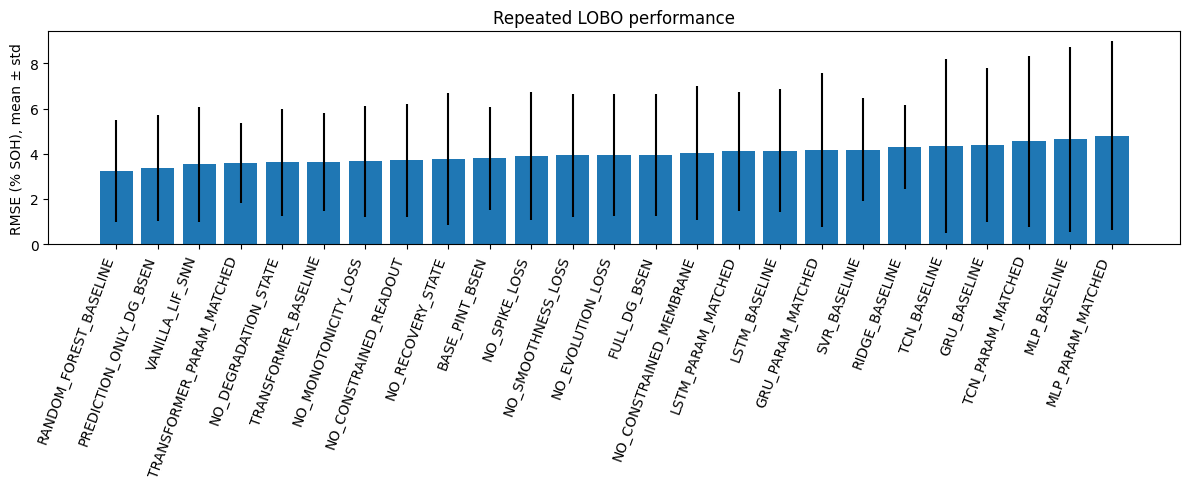

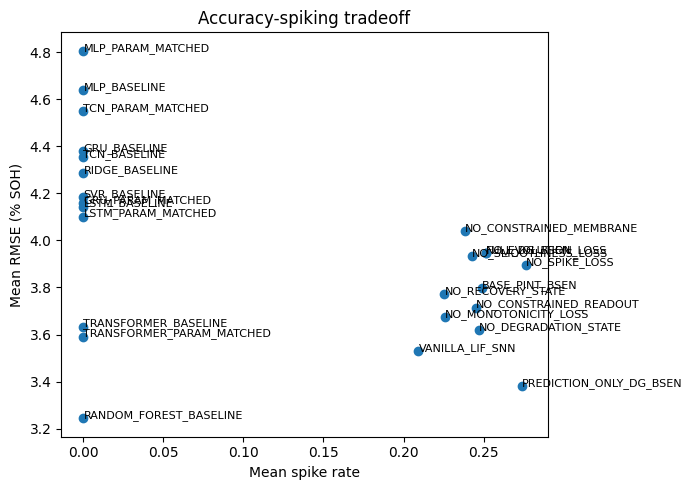

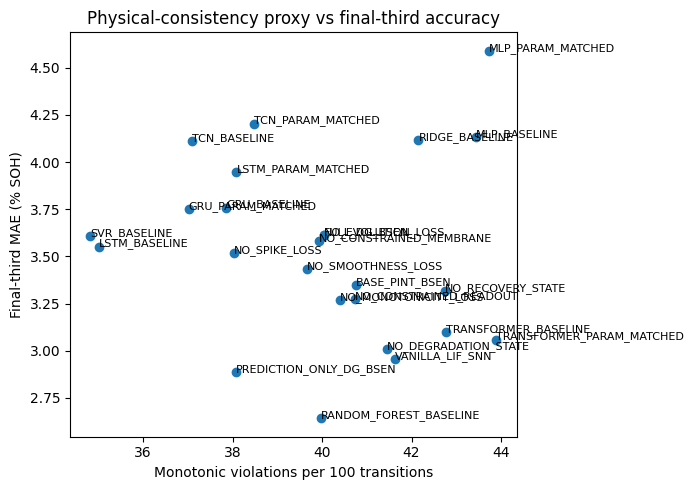

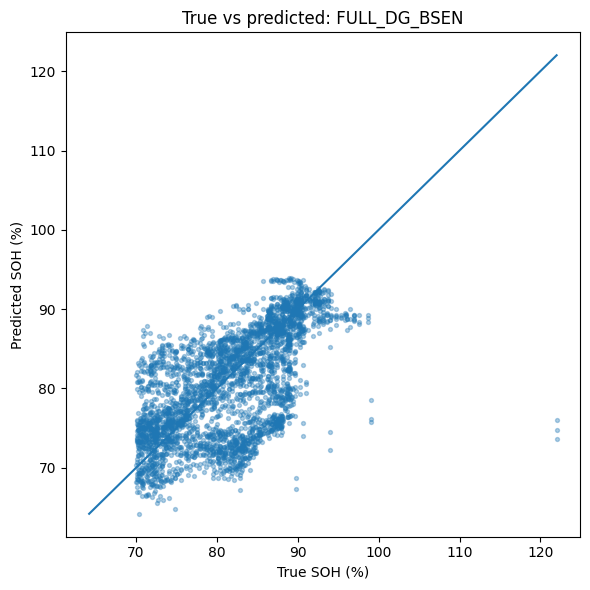

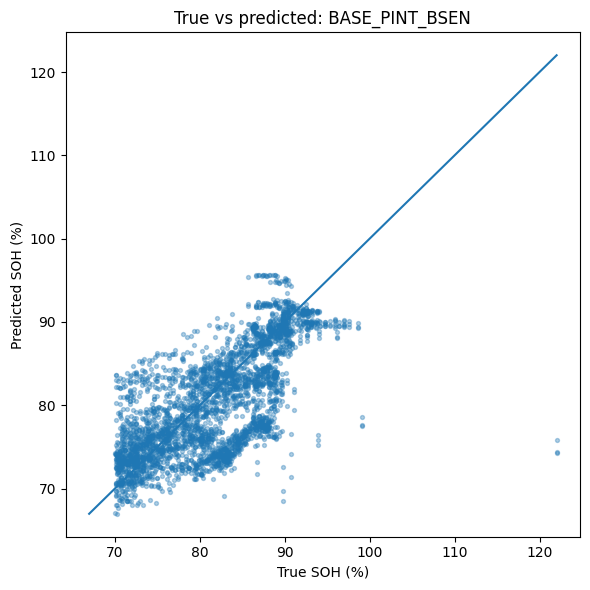

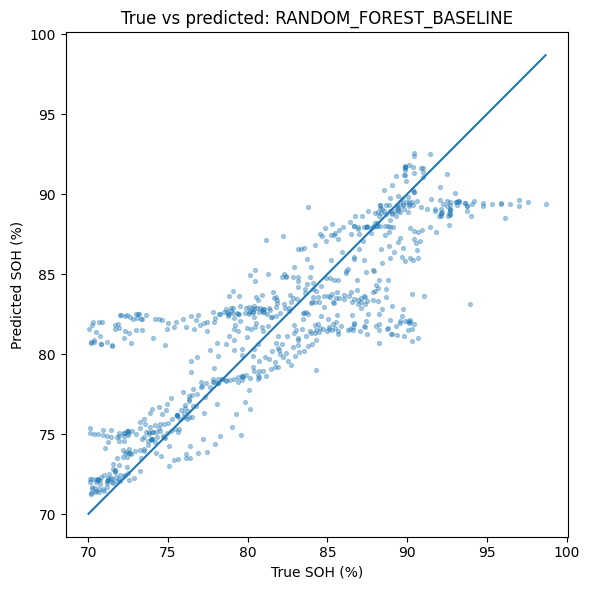

NameError: name 'first_eol_cycle' is not defined

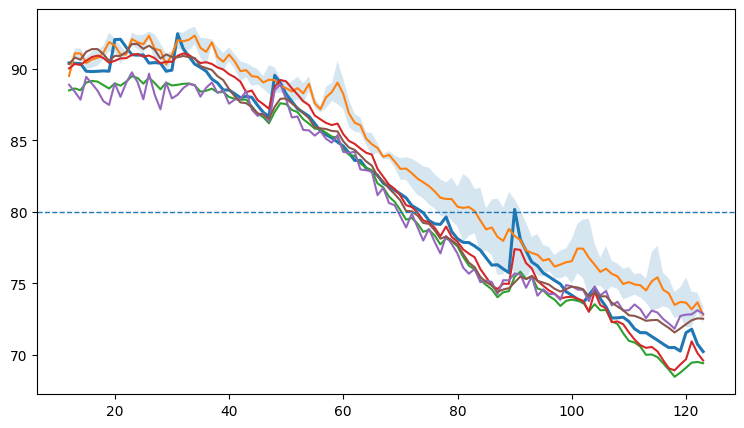

In [24]:
# ============================================================
# Step 9: Paper-oriented plots, grouped diagnostics, and sensitivity runner
# ============================================================


def _safe_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace("%", "pct")


def save_q1_plots(summary_df, results_df, predictions_df, output_dir: Path = OUTPUT_DIR):
    if plt is None:
        print("matplotlib unavailable; skipping plots")
        return

    plot_df = summary_df.sort_values("RMSE_%_mean")
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["experiment"], plot_df["RMSE_%_mean"], yerr=plot_df["RMSE_%_std"].fillna(0))
    plt.xticks(rotation=70, ha="right")
    plt.ylabel("RMSE (% SOH), mean ± std")
    plt.title("Repeated LOBO performance")
    plt.tight_layout()
    plt.savefig(output_dir / "q1_rmse_mean_std.png", dpi=220)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.scatter(summary_df["SpikeRate_mean"], summary_df["RMSE_%_mean"])
    for _, row in summary_df.iterrows():
        plt.annotate(row["experiment"], (row["SpikeRate_mean"], row["RMSE_%_mean"]), fontsize=8)
    plt.xlabel("Mean spike rate")
    plt.ylabel("Mean RMSE (% SOH)")
    plt.title("Accuracy-spiking tradeoff")
    plt.tight_layout()
    plt.savefig(output_dir / "q1_accuracy_spike_tradeoff.png", dpi=220)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.scatter(summary_df["MonotonicViolations_per_100_mean"], summary_df["FinalThirdMAE_%_mean"])
    for _, row in summary_df.iterrows():
        plt.annotate(row["experiment"], (row["MonotonicViolations_per_100_mean"], row["FinalThirdMAE_%_mean"]), fontsize=8)
    plt.xlabel("Monotonic violations per 100 transitions")
    plt.ylabel("Final-third MAE (% SOH)")
    plt.title("Physical-consistency proxy vs final-third accuracy")
    plt.tight_layout()
    plt.savefig(output_dir / "q1_consistency_final_third.png", dpi=220)
    plt.show()

    ranked = summary_df["experiment"].tolist()
    candidates = [MAIN_EXPERIMENT, "BASE_PINT_BSEN", ranked[0]]
    candidates = list(dict.fromkeys([c for c in candidates if c in predictions_df["experiment"].unique()]))

    for exp in candidates:
        g = predictions_df[predictions_df["experiment"] == exp].copy()
        if g.empty:
            continue
        plt.figure(figsize=(6, 6))
        plt.scatter(g["SOH_true"], g["SOH_pred"], s=8, alpha=0.35)
        lo = min(g["SOH_true"].min(), g["SOH_pred"].min())
        hi = max(g["SOH_true"].max(), g["SOH_pred"].max())
        plt.plot([lo, hi], [lo, hi])
        plt.xlabel("True SOH (%)")
        plt.ylabel("Predicted SOH (%)")
        plt.title(f"True vs predicted: {exp}")
        plt.tight_layout()
        plt.savefig(output_dir / f"q1_true_vs_pred_{_safe_name(exp)}.png", dpi=220)
        plt.show()


def save_grouped_per_battery_rmse_plot(results_df, experiments, output_dir: Path = OUTPUT_DIR):
    if plt is None:
        print("matplotlib unavailable; skipping grouped per-battery RMSE plot")
        return pd.DataFrame()

    per = (
        results_df[results_df["experiment"].isin(experiments)]
        .groupby(["test_battery", "experiment"], as_index=False)
        .agg(RMSE_mean=("RMSE_%", "mean"), RMSE_std=("RMSE_%", "std"))
    )
    if per.empty:
        return per
    per.to_csv(output_dir / "q1_grouped_per_battery_rmse.csv", index=False)

    pivot = per.pivot(index="test_battery", columns="experiment", values="RMSE_mean")
    err = per.pivot(index="test_battery", columns="experiment", values="RMSE_std").fillna(0)
    ax = pivot.plot(kind="bar", yerr=err, figsize=(12, 5), capsize=3)
    ax.set_xlabel("Held-out battery")
    ax.set_ylabel("RMSE (% SOH)")
    ax.set_title("Per-battery RMSE comparison")
    plt.tight_layout()
    plt.savefig(output_dir / "q1_grouped_per_battery_rmse.png", dpi=240)
    plt.close()
    return per


def choose_reviewer_comparison_models(summary_df):
    available = set(summary_df["experiment"])
    neural_candidates = [x for x in ["LSTM_PARAM_MATCHED", "GRU_PARAM_MATCHED", "TRANSFORMER_PARAM_MATCHED", "LSTM_BASELINE", "GRU_BASELINE"] if x in available]
    tabular_candidates = [x for x in ["EXTRA_TREES_BASELINE", "RANDOM_FOREST_BASELINE", "SVR_BASELINE", "HGBR_BASELINE"] if x in available]
    models = [MAIN_EXPERIMENT, "VANILLA_LIF_SNN"]
    if neural_candidates:
        models.append(summary_df[summary_df["experiment"].isin(neural_candidates)].sort_values("RMSE_%_mean")["experiment"].iloc[0])
    if tabular_candidates:
        models.append(summary_df[summary_df["experiment"].isin(tabular_candidates)].sort_values("RMSE_%_mean")["experiment"].iloc[0])
    return [m for m in dict.fromkeys(models) if m in available]


def save_battery_level_diagnostic_plots(predictions_df, results_df, main_experiment=MAIN_EXPERIMENT, comparators=None, output_dir: Path = OUTPUT_DIR):
    if plt is None:
        print("matplotlib unavailable; skipping battery-level plots")
        return

    plot_dir = output_dir / "battery_level_plots"
    plot_dir.mkdir(exist_ok=True, parents=True)

    if comparators is None:
        preferred = ["LSTM_PARAM_MATCHED", "GRU_PARAM_MATCHED", "TRANSFORMER_PARAM_MATCHED", "EXTRA_TREES_BASELINE", "SVR_BASELINE", "VANILLA_LIF_SNN"]
        comparators = [x for x in preferred if x in predictions_df["experiment"].unique()]
    plot_experiments = list(dict.fromkeys([main_experiment] + comparators[:4]))

    for battery in sorted(predictions_df["battery_id"].unique()):
        g = predictions_df[predictions_df["battery_id"] == battery].copy()
        if g.empty:
            continue

        true_curve = g.groupby("cycle_number", as_index=False)["SOH_true"].mean().sort_values("cycle_number")

        plt.figure(figsize=(9, 5))
        plt.plot(true_curve["cycle_number"], true_curve["SOH_true"], linewidth=2.2, label="True SOH")

        for exp in plot_experiments:
            eg = g[g["experiment"] == exp].copy()
            if eg.empty:
                continue
            agg = eg.groupby("cycle_number").agg(pred_mean=("SOH_pred", "mean"), pred_std=("SOH_pred", "std")).reset_index().sort_values("cycle_number")
            plt.plot(agg["cycle_number"], agg["pred_mean"], linewidth=1.5, label=exp)
            if exp == main_experiment and agg["pred_std"].notna().any():
                x = agg["cycle_number"].to_numpy()
                m = agg["pred_mean"].to_numpy()
                s = agg["pred_std"].fillna(0).to_numpy()
                plt.fill_between(x, m - s, m + s, alpha=0.18, label=f"{main_experiment} seed ±1 std")

        plt.axhline(EOL_THRESHOLD_SOH, linestyle="--", linewidth=1, label=f"{EOL_THRESHOLD_SOH:.0f}% EOL threshold")
        true_eol = first_eol_cycle(true_curve.rename(columns={"SOH_true": "SOH"}), "SOH", threshold=EOL_THRESHOLD_SOH)
        if np.isfinite(true_eol):
            plt.axvline(true_eol, linestyle=":", linewidth=1, label="True EOL")
        plt.xlabel("Cycle number")
        plt.ylabel("SOH (%)")
        plt.title(f"SOH trajectory, held-out battery {battery}")
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(plot_dir / f"trajectory_{_safe_name(battery)}.png", dpi=240)
        plt.close()

        eg = g[g["experiment"] == main_experiment].copy()
        if not eg.empty:
            agg = eg.groupby("cycle_number").agg(err_mean=("signed_error", "mean"), err_std=("signed_error", "std")).reset_index().sort_values("cycle_number")
            plt.figure(figsize=(9, 4.5))
            plt.axhline(0.0, linewidth=1)
            x = agg["cycle_number"].to_numpy()
            m = agg["err_mean"].to_numpy()
            s = agg["err_std"].fillna(0).to_numpy()
            plt.plot(x, m, linewidth=1.8, label="Mean signed error")
            plt.fill_between(x, m - s, m + s, alpha=0.18, label="Seed ±1 std")
            plt.xlabel("Cycle number")
            plt.ylabel("Prediction error (% SOH)")
            plt.title(f"Error over cycle index, {main_experiment}, {battery}")
            plt.legend(fontsize=8)
            plt.tight_layout()
            plt.savefig(plot_dir / f"error_{_safe_name(main_experiment)}_{_safe_name(battery)}.png", dpi=240)
            plt.close()

            if eg["deg_last_mean"].notna().any():
                dagg = eg.groupby("cycle_number").agg(deg_mean=("deg_last_mean", "mean"), soh_true=("SOH_true", "mean")).reset_index().sort_values("cycle_number")
                plt.figure(figsize=(9, 4.5))
                plt.plot(dagg["cycle_number"], dagg["deg_mean"], linewidth=1.8, label="Latent degradation state")
                plt.xlabel("Cycle number")
                plt.ylabel("Mean latent degradation state")
                plt.title(f"Latent degradation trajectory, {main_experiment}, {battery}")
                plt.legend(fontsize=8)
                plt.tight_layout()
                plt.savefig(plot_dir / f"latent_degradation_{_safe_name(main_experiment)}_{_safe_name(battery)}.png", dpi=240)
                plt.close()

    if main_experiment in results_df["experiment"].unique():
        per_battery = results_df[results_df["experiment"] == main_experiment].groupby("test_battery", as_index=False).agg(
            RMSE_mean=("RMSE_%", "mean"),
            RMSE_std=("RMSE_%", "std"),
            MAE_mean=("MAE_%", "mean"),
            R2_mean=("R2", "mean"),
            EOL_abs_mean=("EOL_AbsError_cycles_mean", "mean"),
            MV100_mean=("MonotonicViolations_per_100", "mean"),
        )
        per_battery.to_csv(output_dir / f"q1_per_battery_metrics_{_safe_name(main_experiment)}.csv", index=False)

    print("Saved battery-level plots to:", plot_dir.resolve())


SENSITIVITY_FACTORS = {
    "history_cycles": [6, 12, 18],
    "num_bins": [10, 20, 40],
    "hidden_size": [48, 74, 96],
    "lambda_mono": [0.0, 0.05, 0.10, 0.20],
    "lambda_smooth": [0.0, 0.01, 0.02, 0.05],
    "lambda_spike": [0.0, 0.0005, 0.001, 0.005],
}


def make_config_id(cfg: BenchmarkConfig):
    parts = [
        f"bins{cfg.num_bins}", f"hist{cfg.history_cycles}", f"h{cfg.hidden_size}",
        f"mono{cfg.lambda_mono}", f"smooth{cfg.lambda_smooth}", f"spike{cfg.lambda_spike}",
        f"sup{cfg.supervision_mode}",
    ]
    return "_".join(str(x).replace(".", "p") for x in parts)


def run_sensitivity_suite(base_cfg: BenchmarkConfig = DEFAULT_CFG, selected_experiments=None):
    rows = []
    selected_experiments = selected_experiments or [MAIN_EXPERIMENT]
    for factor, values in SENSITIVITY_FACTORS.items():
        for value in values:
            cfg = replace(base_cfg, **{factor: value})
            config_id = make_config_id(cfg)
            out_dir = Path(base_cfg.output_dir) / "sensitivity" / factor / str(value).replace(".", "p")
            res, hist, pred, summ, fold_summ, tuning, ablation = run_q1_suite(
                benchmark_cfg=cfg,
                selected_experiments=selected_experiments,
                output_dir=out_dir,
            )
            top = summ[summ["experiment"] == MAIN_EXPERIMENT].copy()
            if not top.empty:
                row = top.iloc[0].to_dict()
                row.update({"factor": factor, "value": value, "config_id": config_id})
                rows.append(row)
    sensitivity_df = pd.DataFrame(rows)
    sensitivity_df.to_csv(Path(base_cfg.output_dir) / "q1_sensitivity_summary.csv", index=False)
    return sensitivity_df

summary_df = pd.read_csv("q1_pint_bsen_outputs_rigorous//q1_summary_by_experiment.csv")
save_q1_plots(summary_df, results_df, predictions_df, output_dir=OUTPUT_DIR)
reviewer_models = choose_reviewer_comparison_models(summary_df)
grouped_per_battery_rmse_df = save_grouped_per_battery_rmse_plot(results_df, reviewer_models, output_dir=OUTPUT_DIR)
save_battery_level_diagnostic_plots(predictions_df, results_df, main_experiment=MAIN_EXPERIMENT, output_dir=OUTPUT_DIR)

if RUN_SENSITIVITY_SUITE:
    sensitivity_df = run_sensitivity_suite(DEFAULT_CFG, selected_experiments=[MAIN_EXPERIMENT])

In [25]:
# ============================================================
# Step 10: Statistical tests and reviewer-facing decision tables
# ============================================================


def bootstrap_ci_mean_diff(diff, n_boot=10000, seed=123, alpha=0.05):
    diff = np.asarray(diff, dtype=np.float64)
    diff = diff[np.isfinite(diff)]
    if len(diff) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(diff, size=(n_boot, len(diff)), replace=True).mean(axis=1)
    return float(np.quantile(boots, alpha / 2)), float(np.quantile(boots, 1 - alpha / 2))


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=np.float64)
    m = len(p)
    order = np.argsort(p)
    adjusted = np.empty(m, dtype=np.float64)
    running = 0.0
    for rank, idx in enumerate(order):
        val = (m - rank) * p[idx]
        running = max(running, val)
        adjusted[idx] = min(1.0, running)
    return adjusted


def add_holm_column(stats_df):
    if stats_df.empty or "wilcoxon_p_raw" not in stats_df.columns:
        return stats_df
    valid_mask = stats_df["wilcoxon_p_raw"].notna().values
    holm = np.full(len(stats_df), np.nan)
    if valid_mask.any():
        holm[valid_mask] = holm_adjust(stats_df.loc[valid_mask, "wilcoxon_p_raw"].values)
    stats_df["holm_p"] = holm
    return stats_df


def make_battery_level_statistical_tests(results_df, reference=MAIN_EXPERIMENT, metric="RMSE_%", output_dir: Path = OUTPUT_DIR):
    battery_model = results_df.groupby(["test_battery", "experiment"], as_index=False)[metric].mean()
    pivot = battery_model.pivot(index="test_battery", columns="experiment", values=metric).dropna(axis=1, how="all")
    if reference not in pivot.columns:
        print(f"Reference experiment {reference} not found; skipping battery-level statistical tests")
        return pd.DataFrame()

    rows = []
    p_raw = []
    for comp in pivot.columns:
        if comp == reference:
            continue
        paired = pivot[[reference, comp]].dropna()
        if len(paired) < 2:
            continue
        diff = paired[comp].values - paired[reference].values
        ci_lo, ci_hi = bootstrap_ci_mean_diff(diff)
        wins = int((diff > 0).sum())
        if wilcoxon is not None and len(diff) >= 2 and np.any(np.abs(diff) > 1e-12):
            try:
                p = float(wilcoxon(diff, alternative="greater", zero_method="wilcox").pvalue)
            except Exception:
                p = np.nan
        else:
            p = np.nan
        p_raw.append(p)
        rows.append({
            "level": "battery_seed_averaged",
            "reference": reference,
            "comparator": comp,
            "metric": metric,
            "n_batteries": int(len(diff)),
            "delta_mean_comparator_minus_reference": float(np.mean(diff)),
            "ci95_low": ci_lo,
            "ci95_high": ci_hi,
            "wins_reference": wins,
            "wilcoxon_p_raw": p,
            "cohens_dz": float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12)) if len(diff) > 1 else np.nan,
        })
    stats_df = add_holm_column(pd.DataFrame(rows))
    if not stats_df.empty:
        stats_df = stats_df.sort_values("delta_mean_comparator_minus_reference", ascending=False)
        stats_df.to_csv(output_dir / "q1_stats_primary_battery_seed_averaged.csv", index=False)
        display(stats_df)
    return stats_df


def make_fold_seed_statistical_tests(results_df, reference=MAIN_EXPERIMENT, metric="RMSE_%", output_dir: Path = OUTPUT_DIR):
    pivot = results_df.pivot_table(
        index=["fold_id", "seed", "test_battery"],
        columns="experiment",
        values=metric,
        aggfunc="mean",
    ).dropna(axis=1, how="all")
    if reference not in pivot.columns:
        print(f"Reference experiment {reference} not found; skipping fold-seed statistical tests")
        return pd.DataFrame()

    complete = pivot.dropna(axis=0, subset=[reference])
    experiments = [c for c in complete.columns if complete[c].notna().all()]

    friedman_p = np.nan
    friedman_stat = np.nan
    if friedmanchisquare is not None and len(experiments) >= 3 and len(complete) >= 2:
        vals = [complete[c].values for c in experiments]
        try:
            friedman_stat, friedman_p = friedmanchisquare(*vals)
        except Exception:
            friedman_stat, friedman_p = np.nan, np.nan

    rows = []
    for comp in experiments:
        if comp == reference:
            continue
        paired = complete[[reference, comp]].dropna()
        if paired.empty:
            continue
        diff = paired[comp].values - paired[reference].values
        ci_lo, ci_hi = bootstrap_ci_mean_diff(diff)
        wins = int((diff > 0).sum())
        if wilcoxon is not None and len(diff) >= 2 and np.any(np.abs(diff) > 1e-12):
            try:
                p = float(wilcoxon(diff, alternative="greater", zero_method="wilcox").pvalue)
            except Exception:
                p = np.nan
        else:
            p = np.nan
        rows.append({
            "level": "fold_seed_battery",
            "reference": reference,
            "comparator": comp,
            "metric": metric,
            "n_pairs": int(len(diff)),
            "delta_mean_comparator_minus_reference": float(np.mean(diff)),
            "ci95_low": ci_lo,
            "ci95_high": ci_hi,
            "wins_reference": wins,
            "wilcoxon_p_raw": p,
            "cohens_dz": float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12)) if len(diff) > 1 else np.nan,
            "friedman_stat_all_complete": float(friedman_stat) if np.isfinite(friedman_stat) else np.nan,
            "friedman_p_all_complete": float(friedman_p) if np.isfinite(friedman_p) else np.nan,
        })
    stats_df = add_holm_column(pd.DataFrame(rows))
    if not stats_df.empty:
        stats_df = stats_df.sort_values("delta_mean_comparator_minus_reference", ascending=False)
        stats_df.to_csv(output_dir / "q1_stats_secondary_fold_seed.csv", index=False)
        display(stats_df)
    return stats_df


primary_stats_df = make_battery_level_statistical_tests(results_df, reference=MAIN_EXPERIMENT, metric="RMSE_%", output_dir=OUTPUT_DIR)
secondary_stats_df = make_fold_seed_statistical_tests(results_df, reference=MAIN_EXPERIMENT, metric="RMSE_%", output_dir=OUTPUT_DIR)


def make_decision_table(summary_df, reference=MAIN_EXPERIMENT, output_dir: Path = OUTPUT_DIR):
    s = summary_df.set_index("experiment")
    rows = []

    def get(exp, metric):
        if exp not in s.index or metric not in s.columns:
            return np.nan
        return float(s.loc[exp, metric])

    if reference not in s.index:
        raise RuntimeError(f"Reference experiment {reference} not found in summary.")

    baseline_pool = [
        "MLP_BASELINE", "LSTM_BASELINE", "GRU_BASELINE", "TCN_BASELINE", "TRANSFORMER_BASELINE",
        "MLP_PARAM_MATCHED", "LSTM_PARAM_MATCHED", "GRU_PARAM_MATCHED", "TCN_PARAM_MATCHED", "TRANSFORMER_PARAM_MATCHED",
        "RIDGE_BASELINE", "SVR_BASELINE", "RANDOM_FOREST_BASELINE", "EXTRA_TREES_BASELINE", "HGBR_BASELINE", "VANILLA_LIF_SNN",
    ]
    available_baselines = [x for x in baseline_pool if x in s.index]
    best_baseline = min(available_baselines, key=lambda x: get(x, "RMSE_%_mean")) if available_baselines else None

    ref_rmse = get(reference, "RMSE_%_mean")
    baseline_rmse = get(best_baseline, "RMSE_%_mean") if best_baseline else np.nan
    rmse_gain_vs_baseline = 100.0 * (baseline_rmse - ref_rmse) / baseline_rmse if np.isfinite(baseline_rmse) and baseline_rmse > 0 else np.nan

    rows.append({
        "Gate": "Accuracy route",
        "Pass condition": "FULL_DG_BSEN beats the best baseline by at least 10% mean RMSE.",
        "Measured": f"reference={reference}, best baseline={best_baseline}, RMSE gain={rmse_gain_vs_baseline:.2f}%",
        "Pass": bool(np.isfinite(rmse_gain_vs_baseline) and rmse_gain_vs_baseline >= 10.0),
    })

    ref_spike = get(reference, "SpikeRate_mean")
    ref_synops = get(reference, "SynOps_per_window_est_mean")
    best_dense_macs = get(best_baseline, "MACs_per_window_est_mean") if best_baseline else np.nan
    efficiency_ratio = best_dense_macs / max(ref_synops, 1e-9) if np.isfinite(best_dense_macs) and np.isfinite(ref_synops) else np.nan
    rmse_gap = 100.0 * (ref_rmse - baseline_rmse) / baseline_rmse if np.isfinite(baseline_rmse) and baseline_rmse > 0 else np.nan

    rows.append({
        "Gate": "Efficiency route",
        "Pass condition": "FULL_DG_BSEN is within 10% RMSE of the best baseline and has at least 3x lower estimated event-driven recurrent synops.",
        "Measured": f"RMSE gap={rmse_gap:.2f}%, dense-MAC/synop ratio={efficiency_ratio:.2f}x, spike={ref_spike:.4f}",
        "Pass": bool(np.isfinite(rmse_gap) and rmse_gap <= 10.0 and np.isfinite(efficiency_ratio) and efficiency_ratio >= 3.0),
    })

    deg_corr = get(reference, "DegState_Corr_with_SOHFade_mean")
    mono = get(reference, "MonotonicViolations_per_100_mean")
    final_third = get(reference, "FinalThirdMAE_%_mean")

    rows.append({
        "Gate": "DG consistency route",
        "Pass condition": "Absolute degradation-state/SOH-fade correlation is at least 0.50 and final-third/monotonicity diagnostics are reported.",
        "Measured": f"deg/fade corr={deg_corr:.3f}, |corr|={abs(deg_corr) if np.isfinite(deg_corr) else np.nan:.3f}, monotonic violations/100={mono:.2f}, final-third MAE={final_third:.3f}%",
        "Pass": bool(np.isfinite(deg_corr) and abs(deg_corr) >= 0.50),
    })

    decision_df = pd.DataFrame(rows)
    decision_df.to_csv(output_dir / "q1_decision_gates.csv", index=False)
    display(decision_df)
    return decision_df


decision_df = make_decision_table(summary_df, reference=MAIN_EXPERIMENT, output_dir=OUTPUT_DIR)

,level,reference,comparator,metric,n_batteries,delta_mean_comparator_minus_reference,ci95_low,ci95_high,wins_reference,wilcoxon_p_raw,cohens_dz,holm_p
6,battery_seed_averaged,FULL_DG_BSEN,MLP_PARAM_MATCHED,RMSE_%,21,0.860379,-0.081087,1.908493,12,0.186862,0.359706,1.0
5,battery_seed_averaged,FULL_DG_BSEN,MLP_BASELINE,RMSE_%,21,0.692073,-0.160680,1.644578,12,0.226184,0.318000,1.0
20,battery_seed_averaged,FULL_DG_BSEN,TCN_PARAM_MATCHED,RMSE_%,21,0.604899,-0.095336,1.390667,12,0.121421,0.337775,1.0
1,battery_seed_averaged,FULL_DG_BSEN,GRU_BASELINE,RMSE_%,21,0.432197,-0.331862,1.287561,11,0.292701,0.219287,1.0
19,battery_seed_averaged,FULL_DG_BSEN,TCN_BASELINE,RMSE_%,21,0.408776,-0.493770,1.437529,7,0.580903,0.174311,1.0
17,battery_seed_averaged,FULL_DG_BSEN,RIDGE_BASELINE,RMSE_%,21,0.341938,-0.604851,1.222085,13,0.177708,0.156906,1.0
18,battery_seed_averaged,FULL_DG_BSEN,SVR_BASELINE,RMSE_%,21,0.237545,-0.271920,0.744174,11,0.160229,0.194266,1.0
2,battery_seed_averaged,FULL_DG_BSEN,GRU_PARAM_MATCHED,RMSE_%,21,0.214758,-0.566338,1.108699,9,0.472872,0.105374,1.0
3,battery_seed_averaged,FULL_DG_BSEN,LSTM_BASELINE,RMSE_%,21,0.198116,-0.262381,0.660700,12,0.247401,0.178536,1.0
4,battery_seed_averaged,FULL_DG_BSEN,LSTM_PARAM_MATCHED,RMSE_%,21,0.155632,-0.328941,0.611782,12,0.226184,0.137638,1.0


,level,reference,comparator,metric,n_pairs,delta_mean_comparator_minus_reference,ci95_low,ci95_high,wins_reference,wilcoxon_p_raw,cohens_dz,friedman_stat_all_complete,friedman_p_all_complete,holm_p
6,fold_seed_battery,FULL_DG_BSEN,MLP_PARAM_MATCHED,RMSE_%,63,0.860379,0.231596,1.526289,35,0.092065,0.324915,49.697004,0.001009,1.000000
5,fold_seed_battery,FULL_DG_BSEN,MLP_BASELINE,RMSE_%,63,0.692073,0.132734,1.297819,35,0.082301,0.291697,49.697004,0.001009,1.000000
19,fold_seed_battery,FULL_DG_BSEN,TCN_PARAM_MATCHED,RMSE_%,63,0.604899,-0.077294,1.347975,35,0.184902,0.206293,49.697004,0.001009,1.000000
1,fold_seed_battery,FULL_DG_BSEN,GRU_BASELINE,RMSE_%,63,0.432197,-0.120480,1.041127,34,0.221611,0.183115,49.697004,0.001009,1.000000
18,fold_seed_battery,FULL_DG_BSEN,TCN_BASELINE,RMSE_%,63,0.408776,-0.398069,1.353367,26,0.772234,0.113505,49.697004,0.001009,1.000000
16,fold_seed_battery,FULL_DG_BSEN,RIDGE_BASELINE,RMSE_%,63,0.341938,-0.255035,0.910465,41,0.028956,0.143086,49.697004,0.001009,0.637021
17,fold_seed_battery,FULL_DG_BSEN,SVR_BASELINE,RMSE_%,63,0.237545,-0.152168,0.639595,35,0.129321,0.148410,49.697004,0.001009,1.000000
2,fold_seed_battery,FULL_DG_BSEN,GRU_PARAM_MATCHED,RMSE_%,63,0.214758,-0.397865,0.944734,31,0.551747,0.078993,49.697004,0.001009,1.000000
3,fold_seed_battery,FULL_DG_BSEN,LSTM_BASELINE,RMSE_%,63,0.198116,-0.302648,0.702500,32,0.213555,0.096976,49.697004,0.001009,1.000000
4,fold_seed_battery,FULL_DG_BSEN,LSTM_PARAM_MATCHED,RMSE_%,63,0.155632,-0.341661,0.686411,30,0.434745,0.074902,49.697004,0.001009,1.000000


,Gate,Pass condition,Measured,Pass
0,Accuracy route,FULL_DG_BSEN beats the best baseline by at lea...,"reference=FULL_DG_BSEN, best baseline=RANDOM_F...",False
1,Efficiency route,FULL_DG_BSEN is within 10% RMSE of the best ba...,"RMSE gap=21.64%, dense-MAC/synop ratio=nanx, s...",False
2,DG consistency route,Absolute degradation-state/SOH-fade correlatio...,"deg/fade corr=0.138, |corr|=0.138, monotonic v...",False
